In [ ]:
!wget -q https://github.com/google/fonts/raw/main/apache/roboto/Roboto-Bold.ttf -O /usr/share/fonts/truetype/Roboto-Bold.ttf

In [ ]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 16.0 MB/s eta 0:00:00


# MWU

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# === Load Data ===
df_male_full = pd.read_excel("plot_ready_data_men-finalfinal.xlsx")
df_female_full = pd.read_excel("plot_ready_data_woman-finalfinal.xlsx")

# Extract question text
questions = df_male_full["Question"]

# Drop unnecessary columns for analysis
df_male = df_male_full.drop(columns=["S Number", "Question"])
df_female = df_female_full.drop(columns=["S Number", "Question"])

# === Mann-Whitney U Test Per Question ===
print("\n--- Mann-Whitney U Test Per Question ---")
results = []

for idx in range(len(df_male)):
    q_text = questions.iloc[idx]
    q_m = df_male.iloc[idx].dropna().values
    q_f = df_female.iloc[idx].dropna().values
    stat, p = mannwhitneyu(q_m, q_f, alternative='two-sided')
    results.append((idx + 1, q_text, stat, p))
    print(f"Q{idx + 1} ({q_text}): U = {stat:.3f}, p = {p:.4f}")


--- Mann-Whitney U Test Per Question ---
Q1 ( How would you rate the content of the information generated by the LLM presented by the robot?): U = 31.500, p = 0.6454
Q2 (I would follow the instructions of the robot.): U = 22.500, p = 0.5673
Q3 (Robots can be trusted as instructors.): U = 26.500, p = 0.9525
Q4 (How would you rate the quality of the robot speech generated by the LLM?): U = 23.000, p = 0.6304
Q5 (I would trust the robot to present course material that is relevant and true. ): U = 28.000, p = 1.0000
Q6 (Was the robot’s behaviour natural and akin to a human instructor?): U = 19.500, p = 0.3555
Q7 (How would you rate your overall experience with the robot's presentation?): U = 23.500, p = 0.6666
Q8 (How engaged did you feel during the robot's presentation?): U = 22.000, p = 0.5514
Q9 (How do you perceive the role of robots in an educational setting in the context of presenting course material?): U = 33.000, p = 0.5329
Q10 (Overall, how satisfied are you with the learning ex

#Data organization

In [ ]:
import pandas as pd
from openpyxl.utils import column_index_from_string


df_full = pd.read_excel("/content/Woman_Responses_paper_complete.xlsx", header=0)


columns_to_drop = ['H','I','M','N','Q','T','U','V','Y','Z','AA','AD','AF','AG','AH','AJ','AK']
drop_indices = [column_index_from_string(col)-1 for col in columns_to_drop]  # Convert to 0-based index


df_dropped = df_full.drop(df_full.columns[drop_indices], axis=1)


df_dropped = df_dropped.iloc[0:6]


df_dropped.to_excel("cleaned_likert_only_woman.xlsx", index=False)
print("✅ Cleaned Likert responses saved to 'cleaned_likert_only.xlsx'")

df_full = pd.read_excel("/content/man_Responses_paper_complete.xlsx", header=0)


columns_to_drop = ['H','I','M','N','Q','T','U','V','Y','Z','AA','AD','AF','AG','AH','AJ','AK']
drop_indices = [column_index_from_string(col)-1 for col in columns_to_drop]  # Convert to 0-based index


df_dropped = df_full.drop(df_full.columns[drop_indices], axis=1)


df_dropped = df_dropped.iloc[0:11]


df_dropped.to_excel("cleaned_likert_only_men.xlsx", index=False)
print("✅ Cleaned Likert responses saved to 'cleaned_likert_only.xlsx'")

✅ Cleaned Likert responses saved to 'cleaned_likert_only.xlsx'
✅ Cleaned Likert responses saved to 'cleaned_likert_only.xlsx'


In [ ]:
import pandas as pd


df = pd.read_excel("/content/cleaned_likert_only_men-3.xlsx")


df_filtered = df.loc[1:].dropna(axis=1, how='all')


df_filtered.loc[0] = df.loc[0]
df_filtered = df_filtered.sort_index()


df_transposed = df_filtered.transpose()


df_transposed = df_transposed.reset_index()


df_transposed = df_transposed.rename(columns={"index": "Question"})


df_transposed.to_excel("plot_ready_data_men.xlsx", index=False)

print("✅ Full question-response matrix saved to 'plot_ready_data_men.xlsx'")

✅ Full question-response matrix saved to 'plot_ready_data_men.xlsx'


#Cronbach

In [ ]:
# ==================== CONFIGURATION ===================== #
EXCEL_PATH = "/content/clean_combined.xlsx"   # Path to your data

CONSTRUCTS = {
    "Perceived Instructional Quality": ['G', 'U', 'V', 'F', 'T', 'D', 'C'],
    "Engagement and Clarity": ['L', 'AD', 'J', 'P', 'H'],
    "Appearance Preferences": ['AA', 'Z'],
    "Comfort with Robot Instructors": ['AB', 'AC', 'X'],
    "Godspeed":    ['AG', 'AH', 'AI', 'AJ', 'AL', 'AM', 'AN'],
}
# ======================================================== #

import pandas as pd, numpy as np
from openpyxl.utils import column_index_from_string
import pingouin as pg

# ---------- Load DataFrame -------------------------------
df = pd.read_excel(EXCEL_PATH)

# ---------- Compute Cronbach's Alpha ---------------------
def cron_alpha_from_letters(letters):
    try:
        indices = [column_index_from_string(l) - 1 for l in letters]
        cols = df.columns[indices]
        alpha = pg.cronbach_alpha(df[cols])[0]
        return round(alpha, 3), cols
    except Exception as e:
        return f"Error: {str(e)}", letters

# ---------- Build Output Table ---------------------------
rows = []
print("📊 Cronbach's Alpha Results (Per Question):\n")

for construct_name, letters in CONSTRUCTS.items():
    alpha, cols_or_letters = cron_alpha_from_letters(letters)
    rows.append([construct_name, f"α = {alpha}", "", ""])
    for ltr, col in zip(letters, cols_or_letters):
        rows.append(["", ltr, col, ""])
        print(f"{construct_name} | α = {alpha} | Question: {col}")
    rows.append(["", "", "", ""])  # blank row between constructs

# ---------- Save to Excel -------------------------------
out_df = pd.DataFrame(rows, columns=["Construct", "Letter", "Question", ""])
out_df.to_excel("formatted_constructs_output.xlsx", index=False)

print("\n💾 Saved construct breakdown with Cronbach's alpha to 'formatted_constructs_output.xlsx'")

📊 Cronbach's Alpha Results (Per Question):

Perceived Instructional Quality | α = 0.698 | Question:  How would you rate the content of the information generated by the LLM presented by the robot?
Perceived Instructional Quality | α = 0.698 | Question: I would follow the instructions of the robot.
Perceived Instructional Quality | α = 0.698 | Question: Robots can be trusted as instructors.
Perceived Instructional Quality | α = 0.698 | Question: How would you rate the quality of the robot speech generated by the LLM?
Perceived Instructional Quality | α = 0.698 | Question: I would trust the robot to present course material that is relevant and true. 
Perceived Instructional Quality | α = 0.698 | Question: Was the robot’s behaviour natural and akin to a human instructor?
Perceived Instructional Quality | α = 0.698 | Question: How would you rate your overall experience with the robot's presentation?
Engagement and Clarity | α = 0.684 | Question: How engaged did you feel during the robot's p

In [ ]:
# ==================== CONFIGURATION ===================== #
EXCEL_PATH = "/content/clean_combined.xlsx"   # path to your data
LETTERS    = ['AB','AC','X']
MIN_SIZE   = 1          # ≥2 items per construct
RESTARTS   = 100        # independent random restarts
ITERATIONS = 4000       # annealing steps per restart
TOP_K      = 5          # report best K partitions
convert_to_numeric = False
# ======================================================== #

import pandas as pd, numpy as np, random, math, time
from openpyxl.utils import column_index_from_string

# ---------- Cronbach's alpha (manual, vectorised) -----------------
def cron_alpha(mat: np.ndarray) -> float:
    k = mat.shape[1]
    if k < 2: return np.nan
    item_var  = mat.var(axis=0, ddof=1)
    total_var = mat.sum(axis=1).var(ddof=1)
    return (k/(k-1)) * (1 - item_var.sum()/total_var) if total_var else np.nan

# ---------- Load dataframe + map Excel letters --------------------
df = pd.read_excel(EXCEL_PATH)
col_labels = {l: df.columns[column_index_from_string(l) - 1] for l in LETTERS}
data       = np.column_stack([df[col_labels[l]].to_numpy(dtype=float) for l in LETTERS])
letter_ids = {l: i for i,l in enumerate(LETTERS)}  # for reporting

# ---------- Helper: evaluate a partition --------------------------
def alpha_per_construct(partition):
    return [cron_alpha(data[:, group]) for group in partition]

# ---------- Generate an initial random partition ------------------
def random_partition():
    shuffled = LETTERS.copy()
    random.shuffle(shuffled)
    max_c = len(LETTERS)//MIN_SIZE
    n_c   = random.randint(2, max_c)
    sizes = [MIN_SIZE]*n_c
    leftover = len(LETTERS) - MIN_SIZE*n_c
    for _ in range(leftover):
        sizes[random.randrange(n_c)] += 1
    idx = 0
    part = []
    for s in sizes:
        part.append([letter_ids[shuffled[idx+j]] for j in range(s)])
        idx += s
    return part

# ---------- Neighbour: move or swap items -------------------------
def neighbour(part):
    part = [grp.copy() for grp in part]
    if random.random() < 0.5 and len(part) > 1:
        # move
        src = random.randrange(len(part))
        dst = random.randrange(len(part))
        while dst == src:
            dst = random.randrange(len(part))
        if len(part[src]) > MIN_SIZE:
            itm = part[src].pop(random.randrange(len(part[src])))
            part[dst].append(itm)
    else:
        # swap
        a, b = random.sample(range(len(part)), 2)
        ia = random.randrange(len(part[a]))
        ib = random.randrange(len(part[b]))
        part[a][ia], part[b][ib] = part[b][ib], part[a][ia]
    part = [g for g in part if g]   # safeguard
    random.shuffle(part)
    return part

# ---------- Simulated annealing search ----------------------------
def anneal():
    part      = random_partition()
    best_part = part
    best_val  = min(alpha_per_construct(part))
    T0 = 1.0
    for step in range(1, ITERATIONS+1):
        T = T0 / step
        cand       = neighbour(part)
        cand_alpha = alpha_per_construct(cand)
        if np.isnan(cand_alpha).any(): continue
        cand_val = min(cand_alpha)
        if cand_val > best_val or math.exp((cand_val - best_val)/T) > random.random():
            part, best_val = cand, cand_val
            best_part = [g.copy() for g in cand]
    return best_part, best_val

# ---------- Main search loop with multiple restarts ---------------
start = time.time()
top = []   # (min_alpha, partition)

for r in range(RESTARTS):
    p, v = anneal()
    top.append((v, p))
    top = sorted(top, key=lambda x: x[0], reverse=True)[:TOP_K]
    if (r+1) % 10 == 0:
        print(f"Restart {r+1}/{RESTARTS}  |  best min α so far = {top[0][0]:.3f}")

elapsed = time.time() - start
print(f"\n⏱️  Finished {RESTARTS} restarts in {elapsed/60:.1f} min.")
print(f"🔎  Top {TOP_K} partitions (by minimum α):")

# ---------- Report + SAVE best partition --------------------------
def show_partition(score, part):
    print(f"\n★  min α = {score:.3f}")
    for i, grp in enumerate(part, 1):
        letters = [LETTERS[j] for j in grp]
        shown   = [str(letter_ids[l]) for l in letters] if convert_to_numeric else letters
        a_val   = cron_alpha(data[:, grp])
        print(f"   Construct {i}: α = {a_val:.3f} | Columns: {', '.join(shown)}")

for score, part in top:
    show_partition(score, part)

# ---------- SAVE BEST RESULT TO EXCEL ------------------------------
best_score, best_part = top[0]
rows = []
for i, grp in enumerate(best_part, 1):
    construct_name = f"Construct {i}"
    letters        = [LETTERS[j] for j in grp]
    qnames         = [col_labels[l] for l in letters]
    a_val          = round(cron_alpha(data[:, grp]), 3)
    rows.append([construct_name, f"α = {a_val}", "", ""])
    for ltr, qn in zip(letters, qnames):
        rows.append(["", ltr, qn, ""])
    rows.append(["", "", "", ""])  # blank row separator

out_df = pd.DataFrame(rows, columns=["Construct", "Letter", "Question", ""])
out_df.to_excel("best_partition.xlsx", index=False)
print("\n💾  Saved best partition details to 'best_partition.xlsx'")

Restart 10/100  |  best min α so far = -0.261
Restart 20/100  |  best min α so far = -0.261
Restart 30/100  |  best min α so far = -0.261
Restart 40/100  |  best min α so far = -0.261
Restart 50/100  |  best min α so far = -0.261
Restart 60/100  |  best min α so far = -0.261
Restart 70/100  |  best min α so far = -0.261
Restart 80/100  |  best min α so far = -0.261
Restart 90/100  |  best min α so far = -0.261
Restart 100/100  |  best min α so far = -0.261

⏱️  Finished 100 restarts in 0.3 min.
🔎  Top 5 partitions (by minimum α):

★  min α = -0.261
   Construct 1: α = -0.261 | Columns: AB, X
   Construct 2: α = nan | Columns: AC

★  min α = nan
   Construct 1: α = nan | Columns: AB
   Construct 2: α = nan | Columns: X
   Construct 3: α = nan | Columns: AC

★  min α = nan
   Construct 1: α = nan | Columns: AC
   Construct 2: α = nan | Columns: X
   Construct 3: α = nan | Columns: AB

★  min α = 0.087
   Construct 1: α = 0.087 | Columns: X, AC
   Construct 2: α = nan | Columns: AB

★  mi

In [ ]:
from openpyxl.utils import column_index_from_string

# === Example input (replace this with your own list) ===
column_letters = ['C', 'D', 'F', 'G', 'J', 'L', 'H', 'P', 'T', 'U', 'V',
                  'X', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD', 'AG', 'AH', 'AI', 'AJ',
                  'AL', 'AM', 'AN']

# === Step 1: Sort alphabetically
sorted_letters = sorted(column_letters, key=lambda x: column_index_from_string(x))

# === Step 2: Create mapping
letter_to_index = {letter: i + 1 for i, letter in enumerate(sorted_letters)}

# === Output mapping
print("Column letter to numeric index mapping:")
for letter in column_letters:
    print(f"{letter} → {letter_to_index[letter]}")

Column letter to numeric index mapping:
C → 1
D → 2
F → 3
G → 4
J → 6
L → 7
H → 5
P → 8
T → 9
U → 10
V → 11
X → 12
Y → 13
Z → 14
AA → 15
AB → 16
AC → 17
AD → 18
AG → 19
AH → 20
AI → 21
AJ → 22
AL → 23
AM → 24
AN → 25


#Shapiro test

In [ ]:
import pandas as pd
from scipy.stats import shapiro


df = pd.read_excel("/content/clean_combined.xlsx")


df_clean = df.loc[1:].dropna(axis=1, how='all')

df_clean.loc[0] = df.loc[0]
df_clean = df_clean.sort_index()


results_list = []

# Run Shapiro-Wilk on each valid column
for col in df_clean.columns:
    try:
        values = pd.to_numeric(df_clean[col], errors='coerce').dropna()
        if len(values) >= 3:
            w_stat, p_val = shapiro(values)
            results_list.append({
                "Question": col,
                "W": round(w_stat, 3),
                "p-value": round(p_val, 4),
                "Normal": "Yes" if p_val > 0.05 else "No"
            })
    except Exception as e:
        print(f"⚠️ Error with column '{col}': {e}")


results = pd.DataFrame(results_list)


results.to_excel("shapiro_results.xlsx", index=False)


print("\n✅ Shapiro-Wilk Test Completed — Results saved to 'shapiro_results.xlsx'\n")

print("✅ Example questions that passed normality:")
print(results[results["Normal"] == "Yes"].head(2).to_string(index=False))

print("\n❌ Example questions that violated normality:")
print(results[results["Normal"] == "No"].head(2).to_string(index=False))


✅ Shapiro-Wilk Test Completed — Results saved to 'shapiro_results.xlsx'

✅ Example questions that passed normality:
                                                                                                 Question     W  p-value Normal
                                 How would you rate the quality of the robot speech generated by the LLM? 0.909   0.1140    Yes
I would prefer to interact with a robot with a humanoid appearance (head, arms, facial expressions etc.). 0.911   0.1217    Yes

❌ Example questions that violated normality:
                                                                 Question     W  p-value Normal
How would you rate your overall experience with the robot's presentation? 0.757   0.0008     No
        Was the robot’s behaviour natural and akin to a human instructor? 0.856   0.0168     No


#Likert Summary

In [ ]:
# ==================== CONFIGURATION ===================== #
EXCEL_PATH = "/content/cleaned_likert_only_men-3.xlsx"   # Path to your data

CONSTRUCTS = {
    "Perceived Instructional Quality": ['G', 'U', 'V', 'F', 'T', 'D', 'C'],
    "Engagement and Clarity": ['L', 'AD', 'J', 'P', 'H'],
    "Appearance Preferences": ['AA', 'Z'],
    "Comfort with Robot Instructors": ['AB', 'AC', 'X'],
    "Godspeed": ['AG', 'AH', 'AI', 'AJ', 'AL', 'AM', 'AN'],
}
# ======================================================== #

import pandas as pd, numpy as np
from openpyxl.utils import column_index_from_string

# ---------- Load DataFrame -------------------------------
df = pd.read_excel(EXCEL_PATH)

# ---------- Compute summary stats ------------------------
def compute_median_iqr(col_data):
    col_data = pd.to_numeric(col_data, errors='coerce').dropna()
    if len(col_data) == 0:
        return np.nan, np.nan
    median = round(np.median(col_data), 2)
    iqr = round(np.percentile(col_data, 75) - np.percentile(col_data, 25), 2)
    return median, iqr

# ---------- Build Output Table ---------------------------
rows = []
print("📊 Likert Median & IQR Summary (Per Question):\n")

for construct_name, letters in CONSTRUCTS.items():
    try:
        indices = [column_index_from_string(l) - 1 for l in letters]
        cols = df.columns[indices]
        rows.append([construct_name, "", "", ""])  # Construct header

        for ltr, col in zip(letters, cols):
            median, iqr = compute_median_iqr(df[col])
            rows.append(["", ltr, col, median, iqr])
            print(f"{construct_name} | {ltr} | {col} → Median: {median}, IQR: {iqr}")
        rows.append(["", "", "", "", ""])  # blank row separator

    except Exception as e:
        rows.append([construct_name, "Error", str(e), "", ""])
        print(f"{construct_name} | Error: {str(e)}")

# ---------- Save to Excel -------------------------------
out_df = pd.DataFrame(rows, columns=["Construct", "Letter", "Question", "Median", "IQR"])
out_df.to_excel("likert_median_iqr_constructs-men.xlsx", index=False)

print("\n💾 Saved Likert median/IQR summaries to 'likert_median_iqr_constructs.xlsx'")

📊 Likert Median & IQR Summary (Per Question):

Perceived Instructional Quality | G |  How would you rate the content of the information generated by the LLM presented by the robot? → Median: 4.0, IQR: 0.5
Perceived Instructional Quality | U | I would follow the instructions of the robot. → Median: 3.0, IQR: 1.0
Perceived Instructional Quality | V | Robots can be trusted as instructors. → Median: 3.0, IQR: 1.0
Perceived Instructional Quality | F | How would you rate the quality of the robot speech generated by the LLM? → Median: 3.0, IQR: 1.5
Perceived Instructional Quality | T | I would trust the robot to present course material that is relevant and true.  → Median: 4.0, IQR: 1.0
Perceived Instructional Quality | D | Was the robot’s behaviour natural and akin to a human instructor? → Median: 2.0, IQR: 1.0
Perceived Instructional Quality | C | How would you rate your overall experience with the robot's presentation? → Median: 3.0, IQR: 1.5
Engagement and Clarity | L | How engaged did yo

#Plot Single


🔍 Plotting construct: Perceived Instructional Quality
Columns: C to R
Rows: 2 to 8

🔍 Plotting construct: Engagement and Clarity
Columns: C to R
Rows: 9 to 13

🔍 Plotting construct: Appearance Preferences
Columns: C to R
Rows: 14 to 15


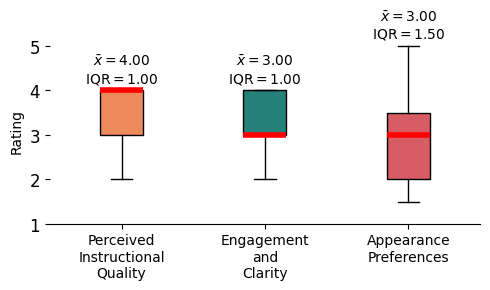

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import openpyxl.utils.cell as xl_utils

# === CONFIGURATION ===
EXCEL_PATH             = "/content/plot_ready_data (1).xlsx"
PLOT_WIDTH_PER_ITEM    = 1
PLOT_HEIGHT            = 3
BOX_WIDTH              = 0.3
ANNOTATION_FONT_SIZE   = 10
LABEL_FONT_SIZE        = 10
YTICK_FONT_SIZE        = 12
SAVE_PATH              = "fig4.svg"

# Font
FONT_NAME              = 'DejaVu Sans'

# === Define constructs (row indices, not letters) ===
constructs_to_plot = {
    "Perceived Instructional Quality": {
        "rows": [0, 1, 2, 3, 4, 5, 6],
        "color": "#ee895b"
    },
    "Engagement and Clarity": {
        "rows": [7, 8, 9, 10, 11],
        "color": "#25817a"
    },
    "Appearance Preferences": {
        "rows": [12, 13],
        "color": "#d85c64"
    },
    # "Comfort with Robot Instructors": {
    #     "rows": [14, 15, 16],
    #     "color": "#84a5c3"
    # },
}

# === Load Data ===
df = pd.read_excel(EXCEL_PATH)

# === Prepare data ===
wrapped_labels = []
aggregated_data = []
colors = []

for name, settings in constructs_to_plot.items():
    row_indices = settings["rows"]
    color = settings["color"]

    df_subset = df.iloc[row_indices]
    responses = df_subset.drop(columns=["S Number", "Question"]).apply(pd.to_numeric, errors='coerce')

    # Excel-like column labels
    data_cols = responses.columns
    col_letters = [xl_utils.get_column_letter(c + 3) for c in data_cols]  # Offset to match column C
    row_numbers = df_subset.index + 2
    print(f"\n🔍 Plotting construct: {name}")
    print(f"Columns: {col_letters[0]} to {col_letters[-1]}")
    print(f"Rows: {row_numbers[0]} to {row_numbers[-1]}")

    combined = responses.median(axis=0, skipna=True)
    aggregated_data.append(combined.values)
    colors.append(color)

    def wrap_label(label, max_words=1):
        words = label.split()
        return '\n'.join([' '.join(words[i:i+max_words]) for i in range(0, len(words), max_words)])

    wrapped_labels.append(wrap_label(name))

# === Plot setup ===
positions = np.arange(len(aggregated_data))
fig, ax = plt.subplots(figsize=(len(aggregated_data) * PLOT_WIDTH_PER_ITEM + 2, PLOT_HEIGHT))

for i, (label, vals, color) in enumerate(zip(wrapped_labels, aggregated_data, colors)):
    vals = vals[~np.isnan(vals)]
    x_bar = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1

    box = ax.boxplot(
        vals,
        positions=[positions[i]],
        widths=BOX_WIDTH,
        patch_artist=True,
        notch=False,
        medianprops=dict(color='red', linewidth=4)
    )
    for patch in box['boxes']:
        patch.set_facecolor(color)

    top_y = box['caps'][1].get_ydata()[0]
    annotation = (
        rf"$\bar{{x}}={x_bar:.2f}$" + "\n" +
        rf"$\mathrm{{IQR}}={iqr:.2f}$"
    )
    ax.text(
        positions[i],
        top_y + 0.1,
        annotation,
        fontsize=ANNOTATION_FONT_SIZE,
        va='bottom',
        ha='center'
    )

# === Final formatting ===
ax.set_xticks(positions)
ax.set_xticklabels(wrapped_labels, fontsize=LABEL_FONT_SIZE, fontname=FONT_NAME)
ax.set_ylabel("Rating", fontsize=LABEL_FONT_SIZE, fontname=FONT_NAME)
ax.tick_params(axis='y', labelsize=YTICK_FONT_SIZE)
ax.set_ylim(bottom=1)  # Set Y-axis to start at 1

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=300, bbox_inches='tight')
plt.show()

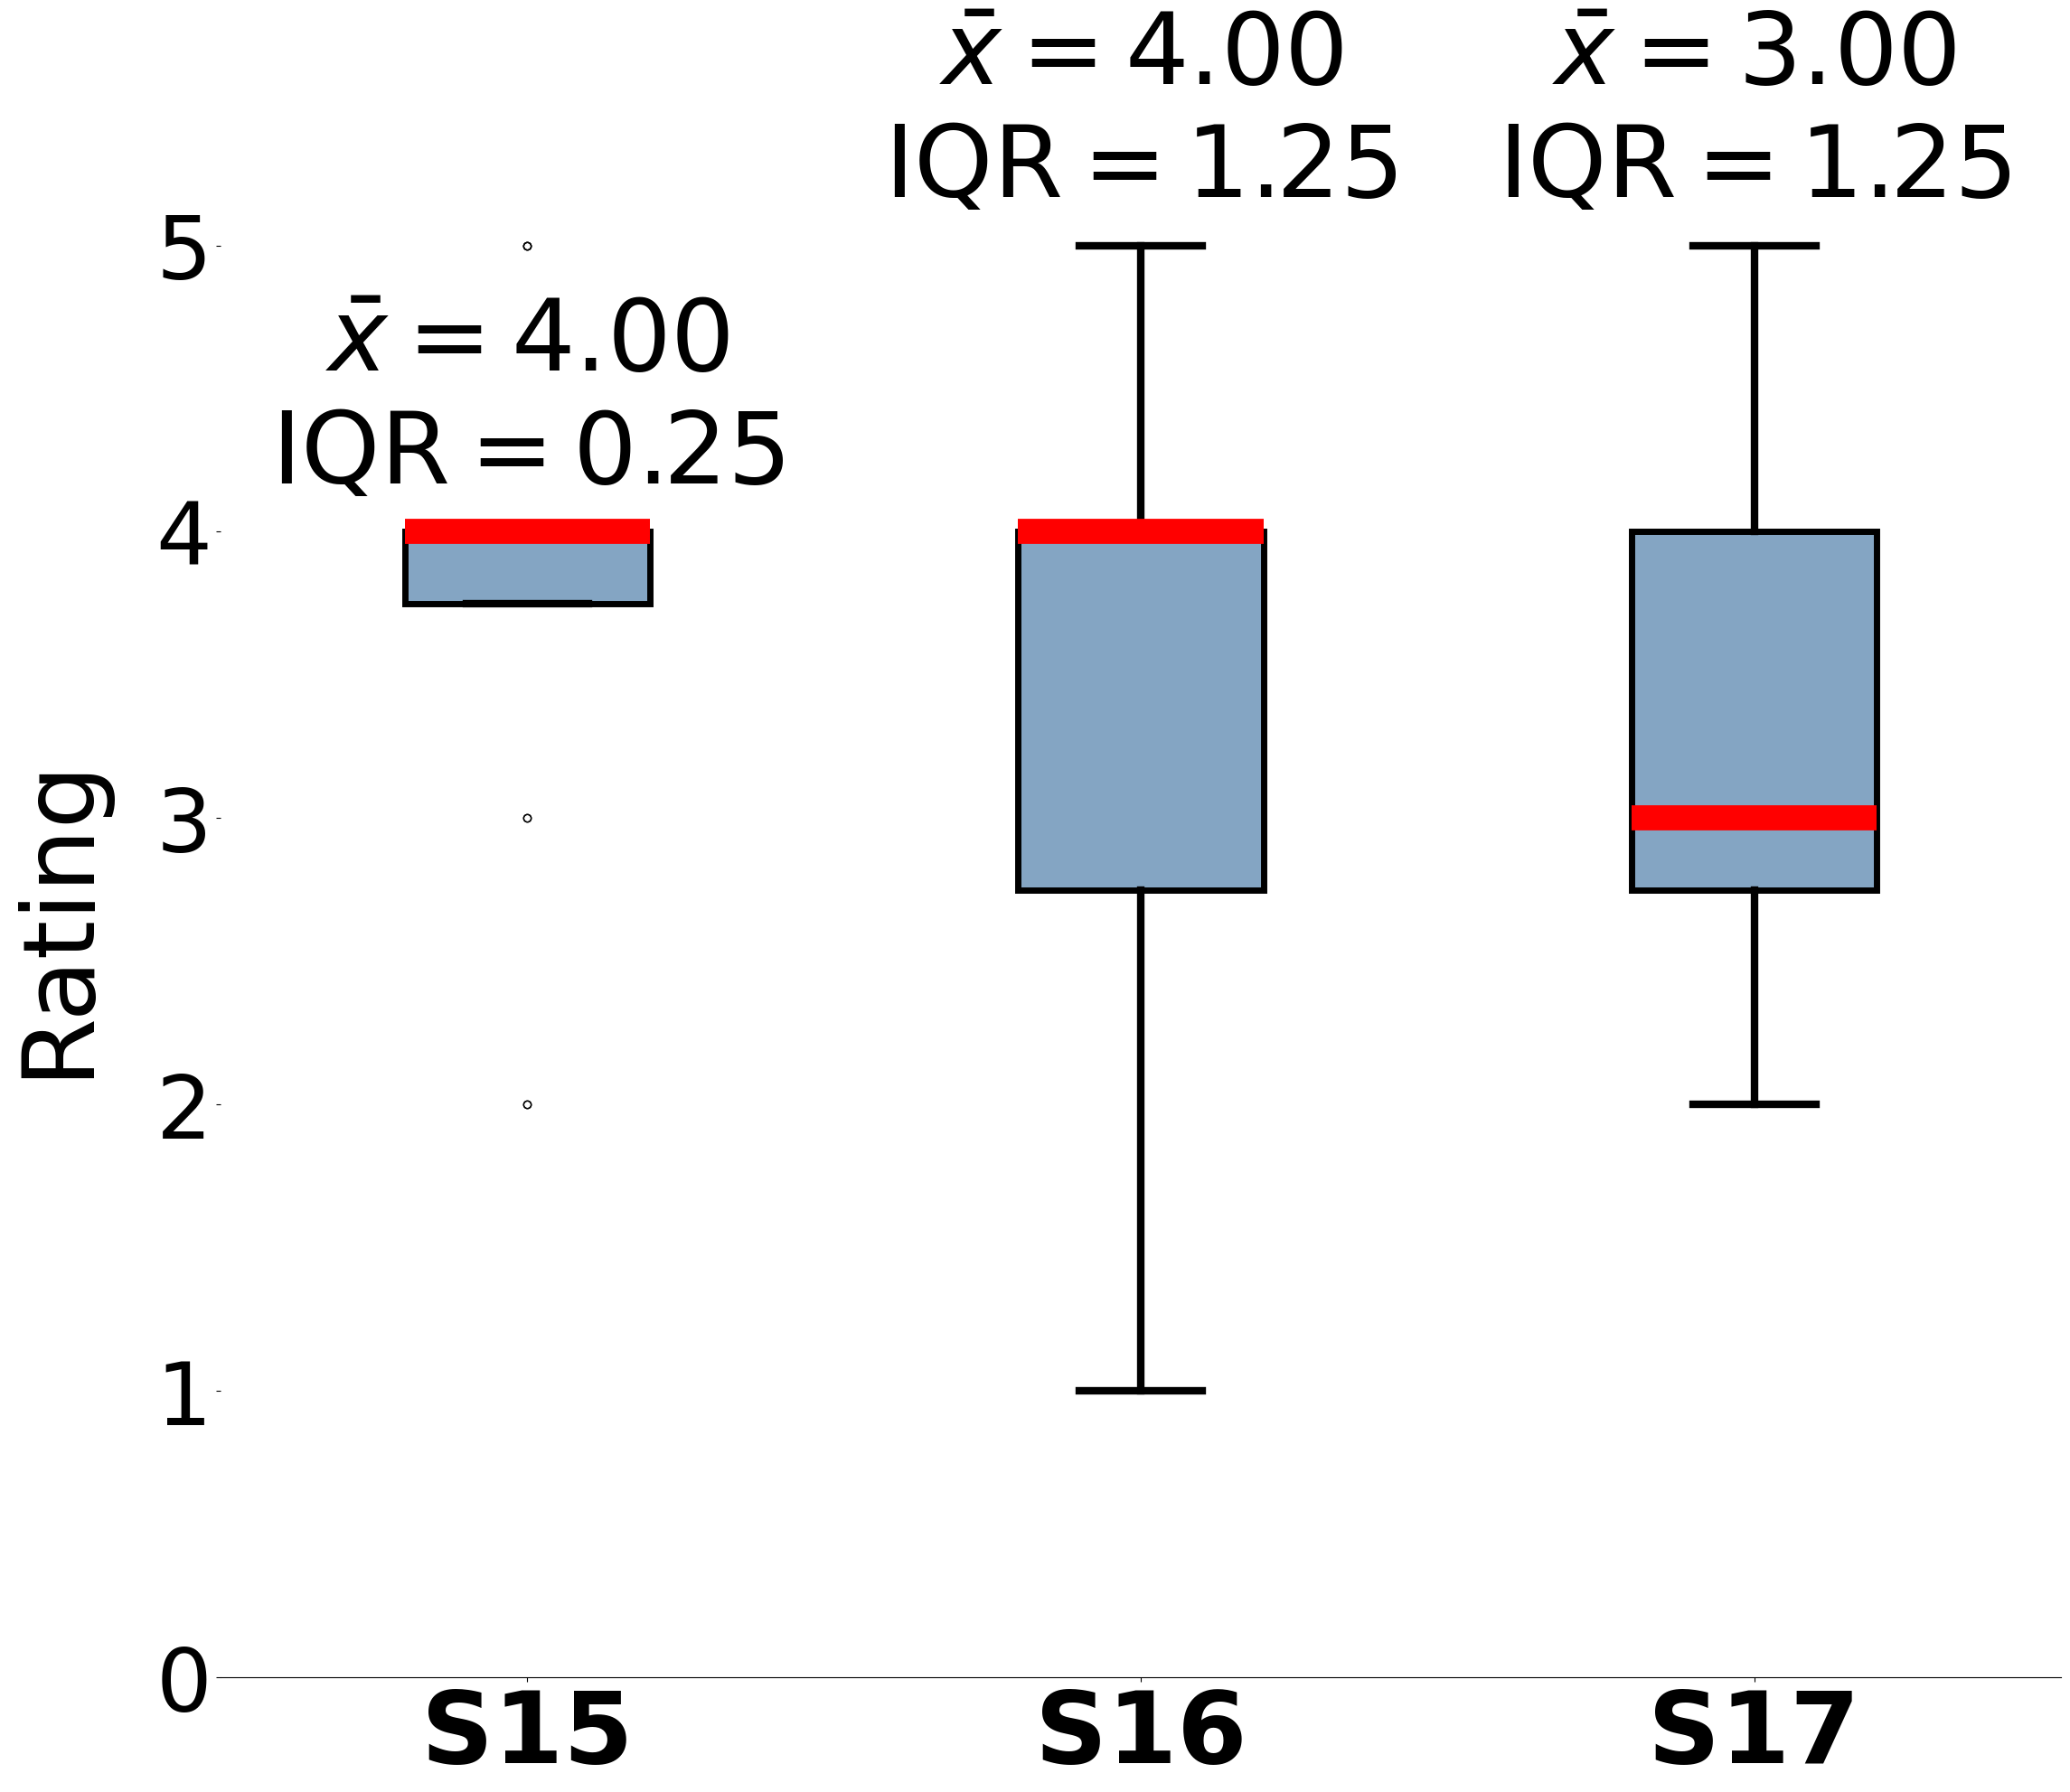

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === CONFIGURATION ===


SAVE_PATH_SVG = "fig8.svg"   # true vector


# Choose which row numbers to plot (0-based: 0 = first row after header)
# rows_to_plot = [0, 1, 2, 3, 4, 5, 6]  # Replace this with desired rows
# box_color          = '#ee895b'


# rows_to_plot=[7, 8, 9, 10, 11]
# box_color          = '#25817a'

# rows_to_plot=[12, 13]
# box_color          = '#d85c64'

rows_to_plot=[14,15,16]


box_color          = '#84a5c3'

# Customize appearance and layout

spacing_between    = 0.5
figsize_x_per_item = 7
figsize_y          = 20
annotation_y_pos   = 0.9       # vertical offset for below–bar annotation
annotation_font    = 80
label_fontsize     = 80
title_fontsize     = 80
ylabel_fontsize    = 80


# === NEW CUSTOMIZATION FIELDS ===
whisker_linewidth  = 6    # thickness of whiskers
cap_linewidth      = 6    # thickness of caps
box_edge_linewidth = 5    # thickness of box edges
median_linewidth   = 20   # thickness of median line
ytick_fontsize     = 70   # fontsize for y-axis tick labels

# === Load Data ===
df = pd.read_excel("/content/plot_ready_data (1).xlsx")

# === Letter to row mapping ===
LETTER_TO_ROW = {
    l: i for i, l in enumerate([
        'C','D','F','G','J','L','H','P','T','U','V',
        'X','Y','Z','AA','AB','AC','AD','AG','AH','AI','AJ',
        'AL','AM','AN'
    ])
}
# rows_to_plot = [LETTER_TO_ROW[l] for l in letters_to_plot]  # ← NO LONGER USED

# === Extract and process data ===
df_plot = df.iloc[rows_to_plot]
questions = df_plot["S Number"]
data = df_plot.drop(columns=["S Number", "Question"]).apply(pd.to_numeric, errors='coerce')

# === Format x-axis labels ===
def wrap_label(label, max_words=1):
    words = label.split()
    return '\n'.join(
        ' '.join(words[i:i+max_words])
        for i in range(0, len(words), max_words)
    )
wrapped_labels = [wrap_label(q) for q in questions]

# === Plot setup ===
positions = np.arange(len(questions))
fig, ax = plt.subplots(
    figsize=(len(questions) * figsize_x_per_item + 2, figsize_y)
)
all_vals = []

# === Plot each question ===
for i, (label, vals) in enumerate(zip(wrapped_labels, data.values)):
    vals = vals[~np.isnan(vals)]
    all_vals.extend(vals)

    x̄ = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1

    # Draw boxplot with customizable styles
    box = ax.boxplot(
        vals,
        positions=[positions[i]],
        widths=0.4,
        patch_artist=True,
        notch=False,
        medianprops=dict(color='red', linewidth=median_linewidth),
        whiskerprops=dict(color='black', linewidth=whisker_linewidth),
        capprops=dict(color='black', linewidth=cap_linewidth),
        boxprops=dict(linewidth=box_edge_linewidth)
    )
    for patch in box['boxes']:
        patch.set_facecolor(box_color)

    # Annotate below each bar
    # Annotate above each box using the top whisker cap position
    top_y = box['caps'][1].get_ydata()[0]
    annotation = (
        rf"$\bar{{x}}={x̄:.2f}$" + "\n" +
        rf"$\mathrm{{IQR}}={iqr:.2f}$"
    )
    ax.text(
        positions[i],
        top_y + 0.1,  # adjust offset as needed
        annotation,
        ha='center',
        va='bottom',
        fontsize=annotation_font,
        clip_on=False
    )

# === Y-limits adjustment ===
all_vals = np.array(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)
padding = (ymax - ymin) * 0.4
lower = ymin - padding * 2
upper = ymax + padding * 0.2

# Option A: clamp axis at zero
ax.set_ylim(bottom=0, top=upper)
# Option B: keep negative space but hide negative ticks
# ax.set_ylim(lower, upper)
# ticks = ax.get_yticks()
# ax.set_yticks(ticks[ticks >= 0])

# === Final formatting ===
ax.set_xticks(positions)
ax.set_xticklabels(
    wrapped_labels,
    fontsize=label_fontsize,
    fontname='DejaVu Sans',
    fontweight='bold'       # make x-labels bold
)
ax.set_ylabel("Rating", fontsize=ylabel_fontsize, fontname='DejaVu Sans', labelpad=40)
ax.tick_params(axis='y', labelsize=ytick_fontsize)

# Remove top, right, and left plot borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()

# Save SVG (vector, editable text)

plt.rcParams["svg.fonttype"] = "path"  # <- force text to vector paths
plt.savefig(SAVE_PATH_SVG, format="svg", bbox_inches="tight")


plt.show()

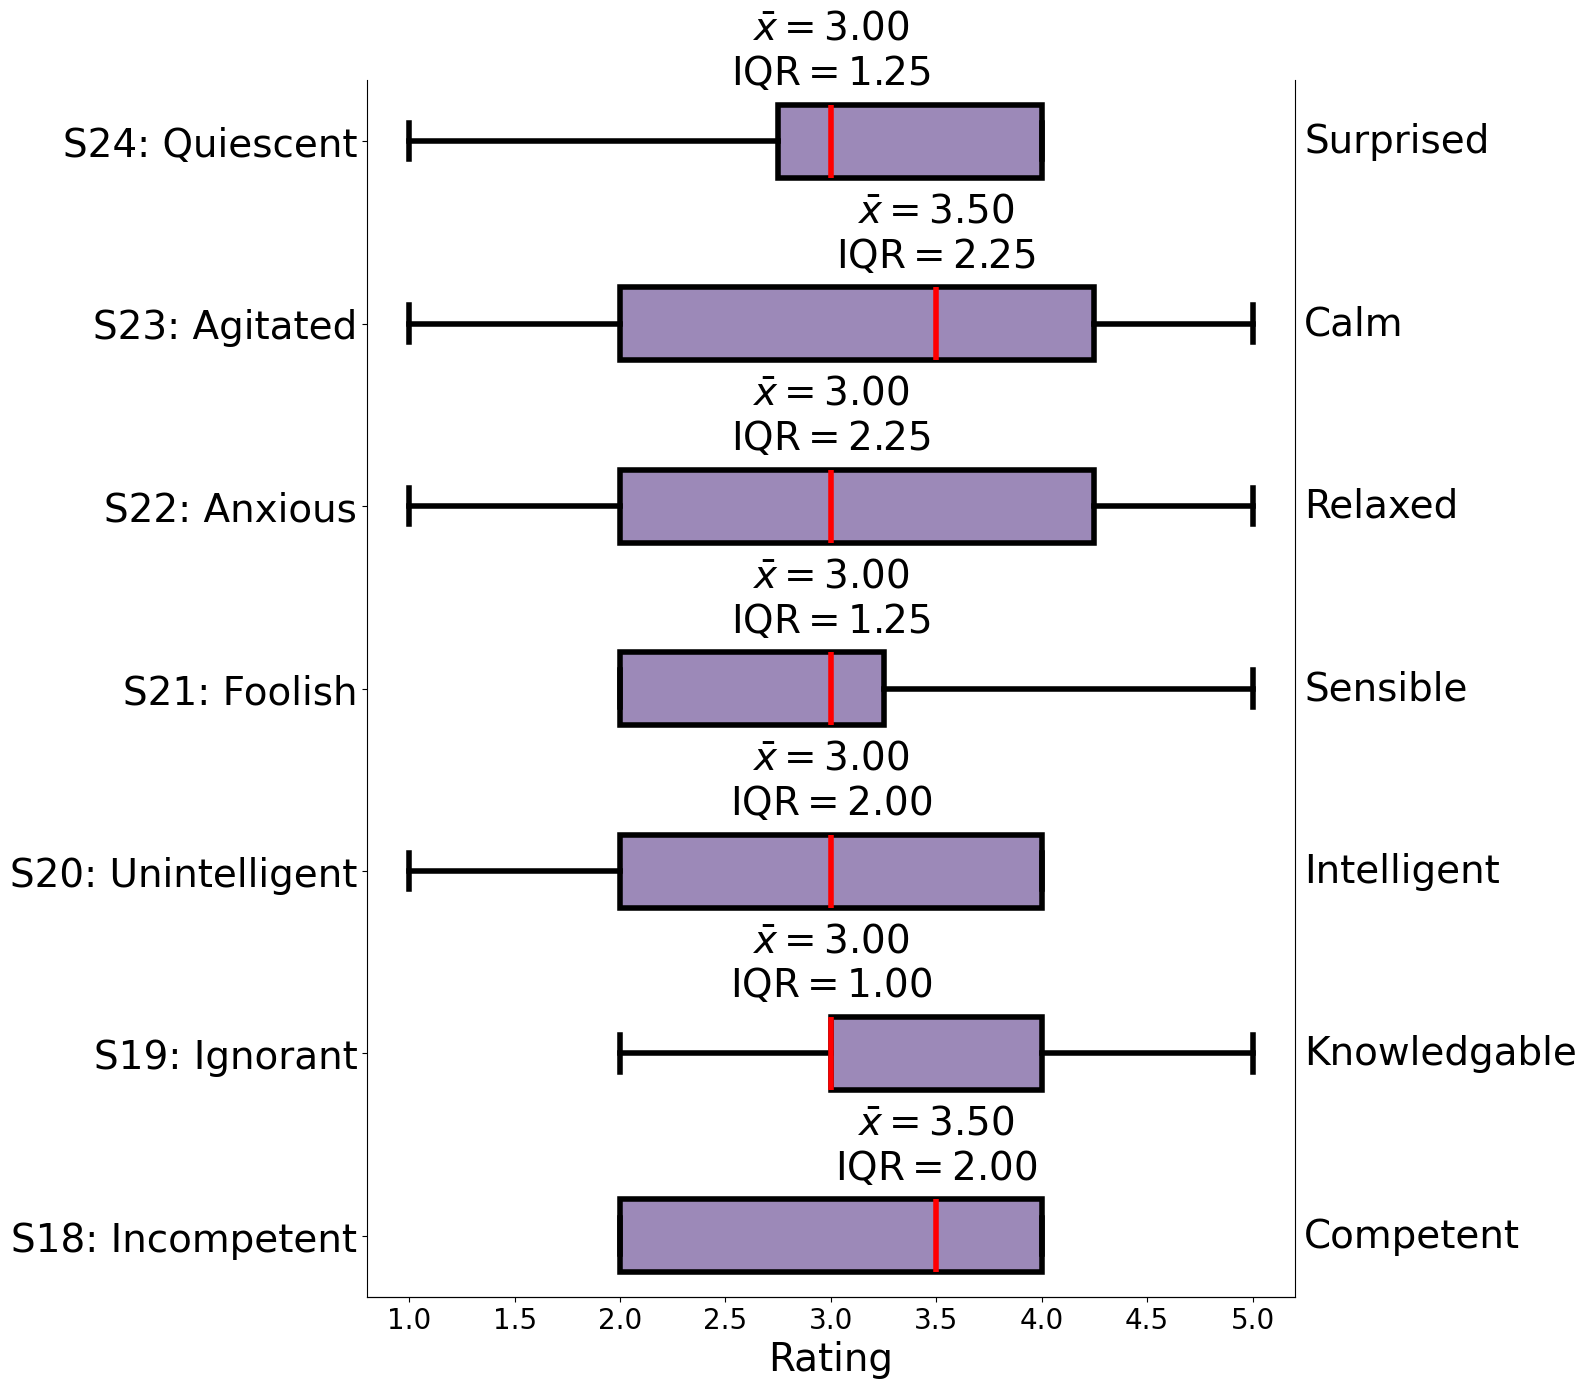

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === CONFIGURATION ===
excel_path = "/content/plot_ready_data (1).xlsx"
rows_to_plot = [17, 18, 19, 20, 21, 22, 23]  # specify which rows (0 = first row after header)
SAVE_PATH_SVG = "fig9.svg"   # true vector

left_labels  = ["S18: Incompetent", "S19: Ignorant", "S20: Unintelligent", "S21: Foolish", "S22: Anxious", "S23: Agitated", "S24: Quiescent"]
right_labels = ["Competent", "Knowledgable", "Intelligent", "Sensible", "Relaxed", "Calm", "Surprised"]

box_color = "#9c89b8"
figsize = (16, 14)
annotation_fontsize = 28
label_fontsize = 28
tick_fontsize = 20
median_linewidth = 4
box_edge_linewidth = 4

# === Load Data ===
df = pd.read_excel(excel_path)
df_plot = df.iloc[rows_to_plot]
questions = df_plot["S Number"]
data = df_plot.drop(columns=["S Number","Question"]).apply(pd.to_numeric, errors='coerce')

# === Setup plot ===
spacing_factor = 1.5  # Increase this for more space between bars
positions = np.arange(len(rows_to_plot)) * spacing_factor
fig, ax = plt.subplots(figsize=figsize)
all_vals = []

# === Plot horizontal boxplots ===
annotation_offset = 0.4  # vertical padding from the boxplot
for i, (vals, l_label, r_label) in enumerate(zip(data.values, left_labels, right_labels)):
    vals = vals[~np.isnan(vals)]
    all_vals.extend(vals)

    x̄ = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1

    box = ax.boxplot(
        vals,
        positions=[positions[i]],
        vert=False,
        widths=0.6,
        patch_artist=True,
        notch=False,
        medianprops=dict(color='red', linewidth=median_linewidth),
        boxprops=dict(linewidth=box_edge_linewidth),
        whiskerprops=dict(linewidth=box_edge_linewidth),
        capprops=dict(linewidth=box_edge_linewidth)
    )

    for patch in box['boxes']:
        patch.set_facecolor(box_color)

    # Annotate with offset
    top_y = positions[i] + annotation_offset
    annotation = f"$\\bar{{x}}={x̄:.2f}$\n$\\mathrm{{IQR}}={iqr:.2f}$"
    ax.text(
        x̄,
        top_y,
        annotation,
        fontsize=annotation_fontsize,
        ha='center',
        va='bottom'
    )

# === Y-axis labels ===
ax.set_yticks(positions)
ax.set_yticklabels(left_labels, fontsize=label_fontsize, ha='right')
ax.tick_params(axis='x', labelsize=tick_fontsize)

# === Right-side labels (mirror)
# === Right-side labels (manual for perfect alignment)
ax2 = ax.twinx()
ax2.set_yticks([])  # Don't use set_yticklabels

for pos, label in zip(positions, right_labels):
    ax2.text(
        1.01, pos,  # slightly right of the axis
        label,
        transform=ax.get_yaxis_transform(),
        fontsize=label_fontsize,
        ha='left',
        va='center'
    )

ax2.tick_params(axis='y', length=0, pad=10)
ax2.spines['top'].set_visible(False)

# === Final formatting ===
ax.set_xlabel("Rating", fontsize=label_fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()

plt.rcParams["svg.fonttype"] = "path"  # <- force text to vector paths
plt.savefig(SAVE_PATH_SVG, format="svg", bbox_inches="tight")
plt.show()

#plot double

In [ ]:
!rm -f /usr/share/fonts/truetype/Roboto-Bold.ttf  # clean old version just in case
!wget -q https://github.com/google/fonts/raw/main/apache/roboto/Roboto-Bold.ttf -O /usr/share/fonts/truetype/Roboto-Bold.ttf

In [ ]:
import matplotlib.font_manager as fm
fonts = sorted(set(f.name for f in fm.fontManager.ttflist))
for f in fonts:
    print(f)

DejaVu Sans
DejaVu Sans Display
DejaVu Sans Mono
DejaVu Serif
DejaVu Serif Display
Humor Sans
Liberation Mono
Liberation Sans
Liberation Sans Narrow
Liberation Serif
STIXGeneral
STIXNonUnicode
STIXSizeFiveSym
STIXSizeFourSym
STIXSizeOneSym
STIXSizeThreeSym
STIXSizeTwoSym
cmb10
cmex10
cmmi10
cmr10
cmss10
cmsy10
cmtt10


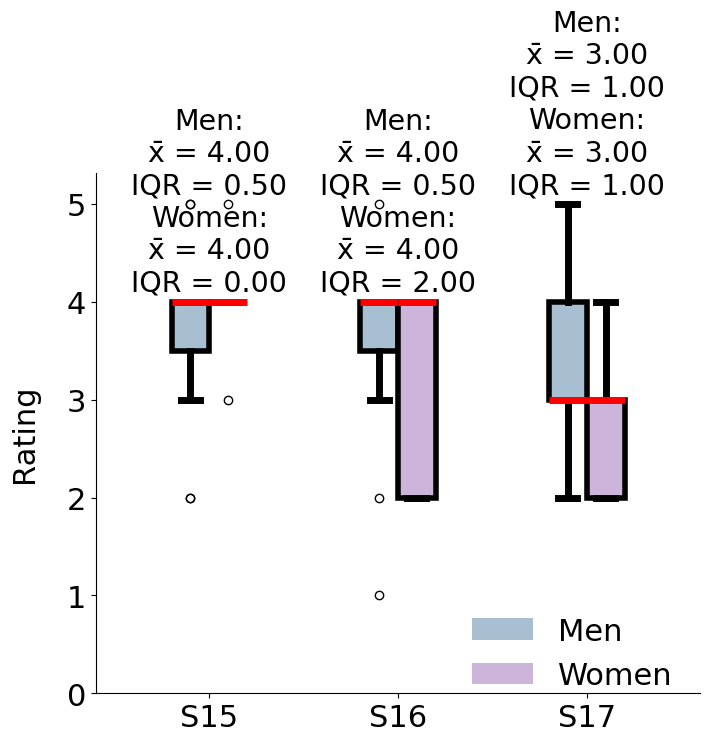

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib as mpl

# === CONFIGURATION ===

# Input files
EXCEL_PATH_A = "/content/plot_ready_data_men-finalfinal.xlsx"
EXCEL_PATH_B = "/content/plot_ready_data_woman-finalfinal.xlsx"
# group_color_gender= ["#8b76a8","#b5a1d1"]     # Godspeed Scale

GROUP_LABELS = ["Men", "Women"]
# GROUP_COLORS = ['#8b76a8', '#b5a1d1']
mpl.rcParams['hatch.linewidth'] = 6  # default is 1.0 — bump this up for thicker hatch lines
# Median line and style
MEDIAN_COLOR = 'red'  # customize color
MEDIAN_LINEWIDTH = 5    # customize thickness

# Box and whisker line style
BOX_LINEWIDTH = 5
WHISKER_LINEWIDTH = 5

# Font
YTICK_FONTNAME = 'DejaVu Sans'
YTICK_FONTSIZE = 22


# spacing_between    = 8              # horizontal spacing between boxes
# figsize_x_per_item = 8              # width per item
# figsize_y          = 30             # figure height
# annotation_font    = 140            # annotation font size
# annotation_font    = 80
# label_fontsize     = 75
# title_fontsize     = 80
# ylabel_fontsize    = 80


spacing_between    = 1            # horizontal spacing between boxes.   1 for per
figsize_x_per_item = 2.4              # width per item
figsize_y          = 7.5             # figure height
# annotation_font    = 250            # annotation font size
annotation_font    = 41
label_fontsize     = 22
title_fontsize     = 40
ylabel_fontsize    = 22



annotation_gap     = 0.7  # ⮅️ Controls spacing between male/female annotations

SAVE_PATH_SVG = "fig15.svg"   # true vector




# rows_to_plot = [0, 1, 2, 3, 4, 5, 6]  # Replace this with desired rows
# GROUP_COLORS = ['#e76f51', '#f4a261']



# rows_to_plot=[7, 8, 9, 10, 11]
# GROUP_COLORS = ['#264653', '#2a9d8f']


# rows_to_plot=[12, 13]
# GROUP_COLORS = ['#b23a48', '#f08080']


rows_to_plot=[14,15,16]
GROUP_COLORS = ['#a8bfd1', '#cdb4db']




def load_data(path):
    df = pd.read_excel(path)
    df_plot = df.iloc[rows_to_plot]
    questions = df_plot["S Number"]
    data = df_plot.drop(columns=["S Number","Question"]).apply(pd.to_numeric, errors='coerce')
    return questions, data

questions, data_a = load_data(EXCEL_PATH_A)
_, data_b = load_data(EXCEL_PATH_B)

def wrap_label(label, max_words=1):
    words = label.split()
    return '\n'.join([' '.join(words[i:i + max_words]) for i in range(0, len(words), max_words)])

wrapped_labels = [wrap_label(q) for q in questions]

positions = np.arange(len(wrapped_labels))
fig, ax = plt.subplots(figsize=(len(wrapped_labels) * figsize_x_per_item, figsize_y))
all_vals = []

box_width = 0.2

for i, label in enumerate(wrapped_labels):
    group_data = [data_a.values[i], data_b.values[i]]

    for j, vals in enumerate(group_data):
        vals = vals[~np.isnan(vals)]
        all_vals.extend(vals)
        x̄ = np.median(vals)
        q1 = np.percentile(vals, 25)
        q3 = np.percentile(vals, 75)
        iqr = q3 - q1
        offset = (-1 if j == 0 else 1) * box_width / 2

        # Draw boxplot with custom styles
        box = ax.boxplot(
            vals,
            positions=[positions[i] + offset],
            widths=box_width,
            patch_artist=True,
            notch=False,
            medianprops=dict(color=MEDIAN_COLOR, linewidth=MEDIAN_LINEWIDTH),
            boxprops=dict(linewidth=BOX_LINEWIDTH),
            whiskerprops=dict(linewidth=WHISKER_LINEWIDTH),
            capprops=dict(linewidth=WHISKER_LINEWIDTH)
        )
        for patch in box['boxes']:
            if j == 1:  # Women (patterned)
                patch.set_facecolor(GROUP_COLORS[j])         # Use original fill color
                patch.set_edgecolor('black')                 # High contrast edge
                patch.set_linewidth(4)                       # Thicker outline
                patch.set_hatch('')                         # Pattern
            else:  # Men (solid)
                patch.set_facecolor(GROUP_COLORS[j])
                patch.set_edgecolor('black')
                patch.set_linewidth(4)

        # Compute and annotate once for both groups
        if j == 0:
            vals_m = vals
            x̄_m = np.median(vals_m)
            iqr_m = np.percentile(vals_m, 75) - np.percentile(vals_m, 25)
            box_m = box  # store boxplot object for men
        else:
            vals_f = vals
            x̄_f = np.median(vals_f)
            iqr_f = np.percentile(vals_f, 75) - np.percentile(vals_f, 25)
            box_f = box  # store boxplot object for women

            # Get y-coordinates of upper whisker caps (caps[1] is the top)
            top_m = box_m['caps'][1].get_ydata()[0]
            top_f = box_f['caps'][1].get_ydata()[0]
            top_y = max(top_m, top_f)

            annotation = (
                "Men:" + "\n"
                + f"x̄ = {x̄_m:.2f}" + "\n"
                + f"IQR = {iqr_m:.2f}" + "\n"
                + "Women:" + "\n"
                + f"x̄ = {x̄_f:.2f}" + "\n"
                + f"IQR = {iqr_f:.2f}"
            )

            ax.text(
                positions[i],
                top_y + 0.05,  # small offset for visual clarity
                annotation,
                ha='center',
                va='bottom',
                fontweight='medium',    # Heavier than 'normal'
                fontsize=annotation_font * 0.5,
                # fontweight='bold',
                clip_on=False
            )

# Y-limits
all_vals = np.array(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)
padding = (ymax - ymin) * 0.4
lower = ymin - padding * 2
upper = ymax + padding * 0.2

# Option A: clamp axis at zero
ax.set_ylim(bottom=0, top=upper)

# Final formatting
ax.set_xticks(positions)
ax.set_xticklabels(wrapped_labels, fontsize=label_fontsize, fontname='DejaVu Sans')
ax.set_ylabel("Rating", fontsize=ylabel_fontsize, fontname='DejaVu Sans', labelpad=20)
# ax.set_title(plot_title, fontsize=title_fontsize, fontname='DejaVu Sans')
ax.tick_params(axis='y', labelsize=YTICK_FONTSIZE)
for label in ax.get_yticklabels():
    label.set_fontname(YTICK_FONTNAME)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# keep 'left' and 'bottom' visible (these are Y and X axes)

# Legend
legend_handles = [
    Patch(facecolor=GROUP_COLORS[0], label=GROUP_LABELS[0]),
    Patch(facecolor=GROUP_COLORS[1], hatch='', label=GROUP_LABELS[1])
]
ax.legend(
    handles=legend_handles,
    loc='upper right',
    bbox_to_anchor=(1, 0.2),  # ⬅️ move legend upward
    fontsize=22,
    frameon=False
)
# ax.legend(
#     handles=legend_handles,
#     loc='upper right',
#     bbox_to_anchor=(1, 0.2),  # ⬅️ move legend upward
#     fontsize=100,
#     frameon=False
# )

plt.tight_layout()
plt.rcParams["svg.fonttype"] = "path"  # <- force text to vector paths
plt.savefig(SAVE_PATH_SVG, format="svg", bbox_inches="tight")
plt.show()


--- Perceived Instructional Quality ---
Men:
   0  1  2  3  4  5  6  7  8  9  10
0  2  4  3  4  5  4  3  4  4  4   4
1  4  4  3  4  3  4  3  3  3  2   4
2  2  2  3  4  4  3  3  1  4  3   3
3  2  4  3  4  4  5  3  2  3  1   3
4  2  4  3  4  4  4  2  5  5  3   4
5  1  4  2  3  2  2  2  2  2  3   3
6  2  4  3  4  3  2  3  2  4  4   4
Women:
   0  1  2  3  4
0  4  3  3  4  4
1  4  4  4  3  3
2  4  2  4  2  3
3  4  3  3  3  4
4  4  4  4  2  4
5  3  4  2  2  3
6  4  4  2  3  4
MWU Test → U = 24.000, p = 0.7027

--- Engagement and Clarity ---
Men:
    0  1  2  3  4  5  6  7  8  9  10
7   3  2  3  3  2  2  4  1  2  3   4
8   4  4  3  4  2  4  3  4  4  3   3
9   2  4  3  4  2  3  3  2  4  4   4
10  4  5  4  4  3  3  3  4  4  3   4
11  2  4  2  4  2  4  4  3  2  4   4
Women:
    0  1  2  3  4
7   4  2  2  3  4
8   4  1  4  3  3
9   4  2  2  3  4
10  4  3  2  3  5
11  4  2  2  3  2
MWU Test → U = 32.000, p = 0.6252

--- Appearance Preferences ---
Men:
    0  1  2  3  4  5  6  7  8  9  10
12  4  

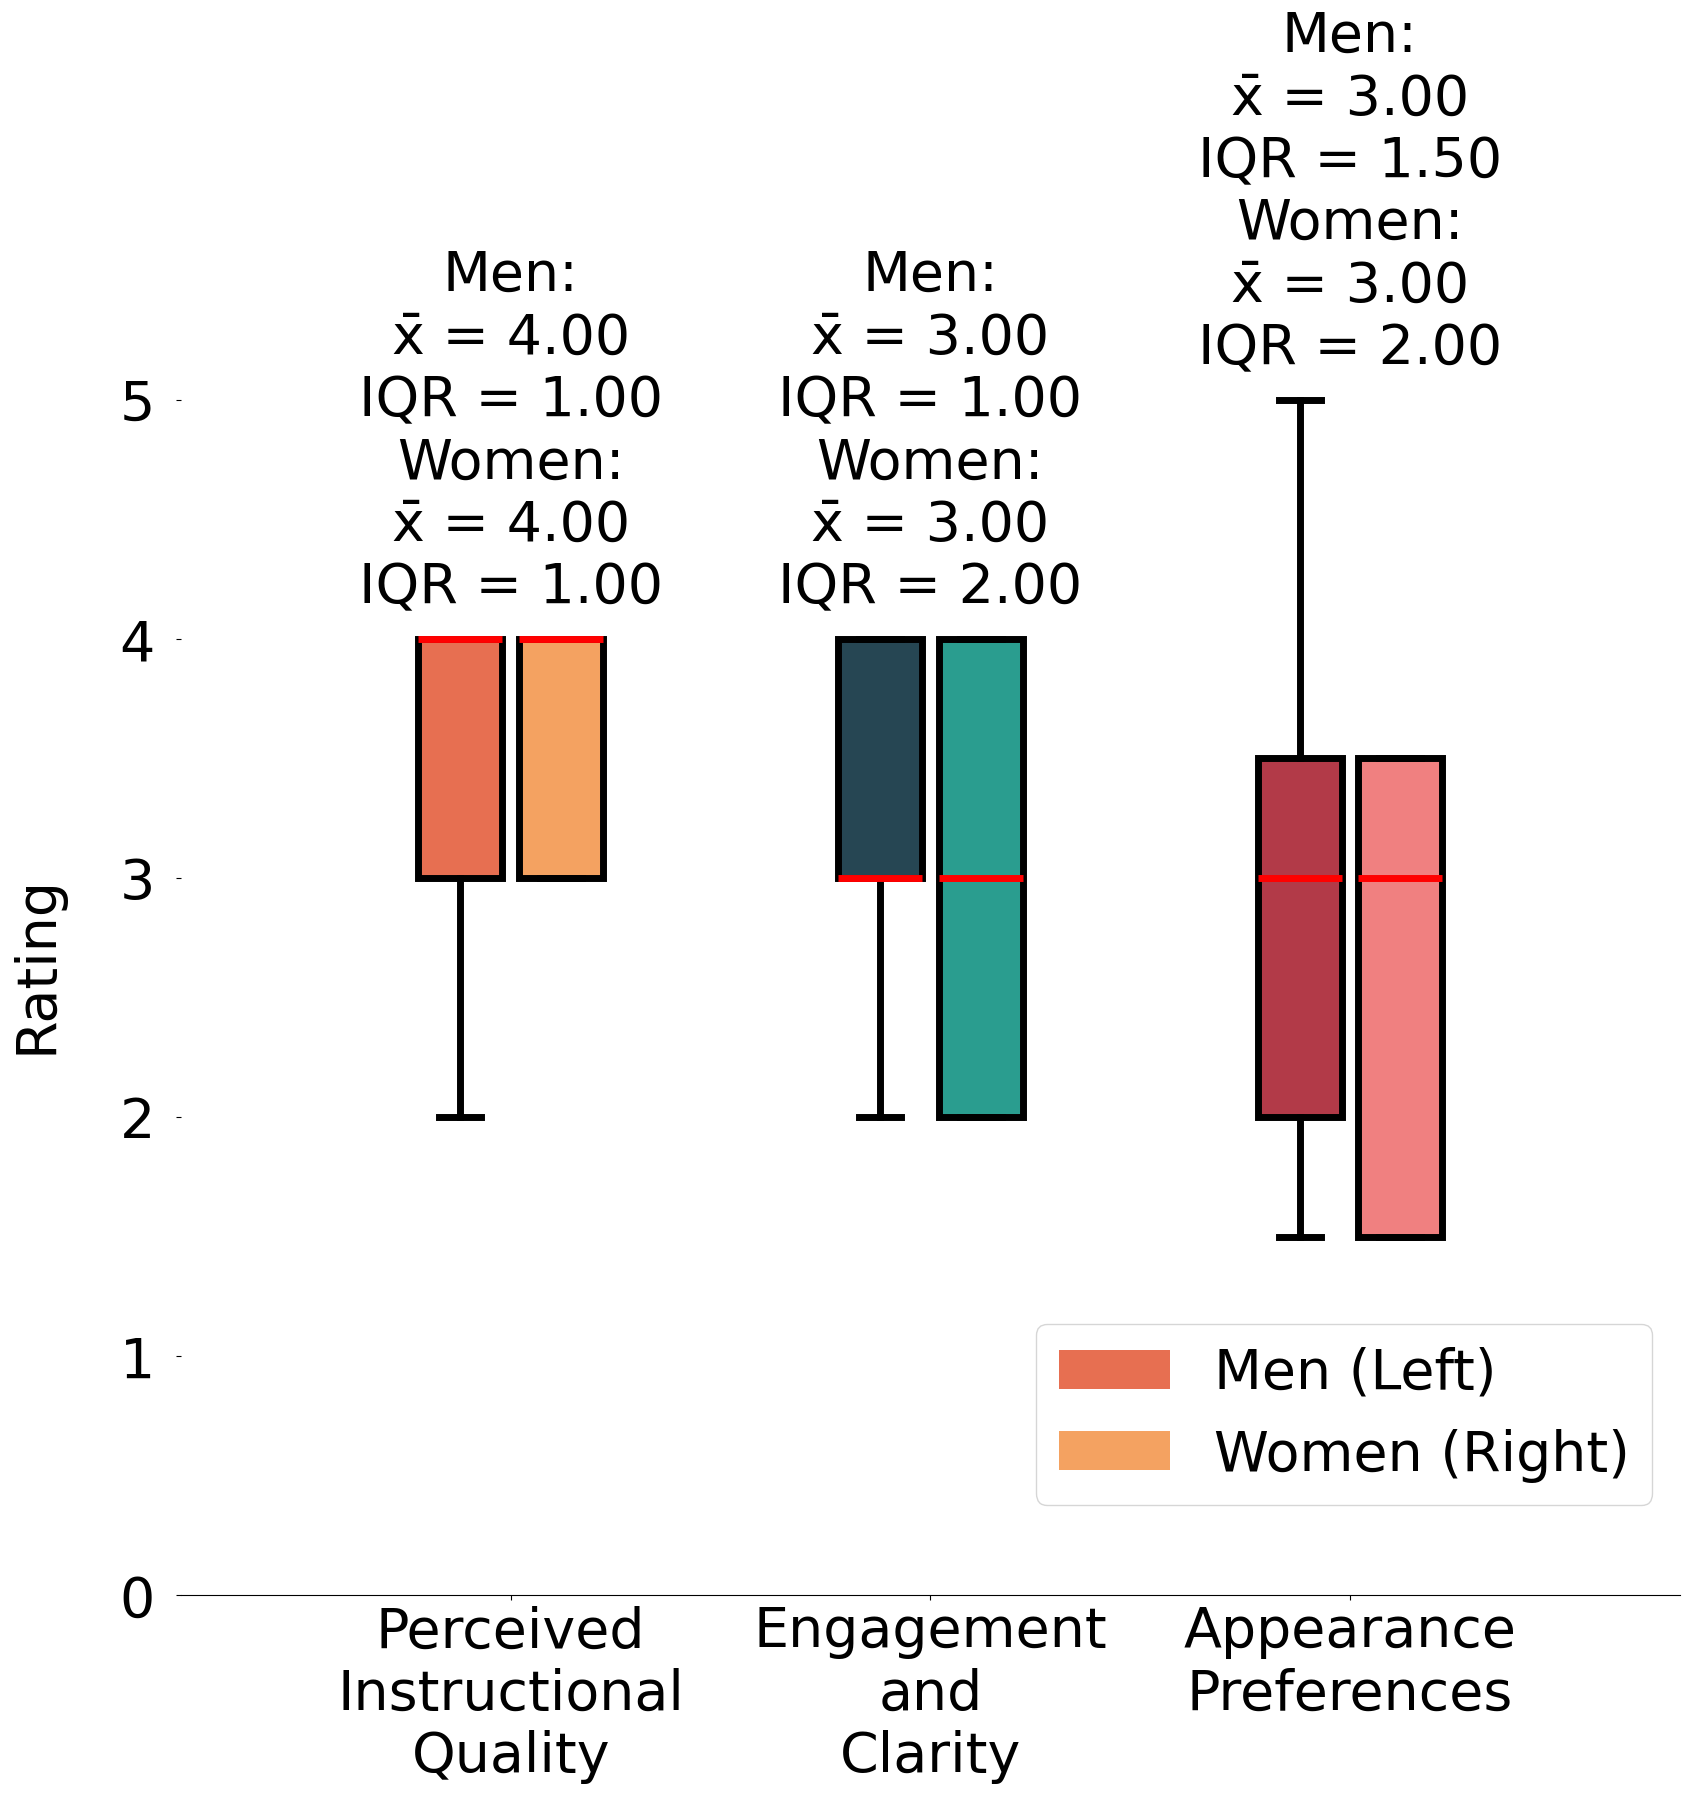

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu  # added for MWU calculation

# === CONFIGURATION ===
construct_spacing = 1.5
box_width = 0.3
fig_width, fig_height = 17, 18
label_fontsize, annotation_fontsize = 40, 40
ylabel_fontsize, ytick_fontsize = 40, 40


SAVE_PATH_SVG = "fig11.svg"   # true vector

# === ROW INDEX VERSION ===
constructs_to_plot = {
    "Perceived Instructional Quality": {
        "rows": [0, 1, 2, 3, 4, 5, 6],
        "color_male": "#e76f51",
        "color_female": "#f4a261"
    },
    "Engagement and Clarity": {
        "rows": [7, 8, 9, 10, 11],
        "color_male": "#264653",
        "color_female": "#2a9d8f"
    },
    "Appearance Preferences": {
        "rows": [12, 13],
        "color_male": "#b23a48",
        "color_female": "#f08080"
    },
    # "Comfort with Robot Instructors": {
    #     "rows": [14, 15, 16],
    #     "color_male": "#a8bfd1",
    #     "color_female": "#cdb4db"
    # },
    # "Godspeed": {
    #     "rows": [17, 18, 19,20,21,22,23],
    #      "color_male": "#a8bfd1",
    #      "color_female": "#cdb4db"
    #  },
}

# === Load Data ===
df_male = pd.read_excel("/content/plot_ready_data_men-finalfinal.xlsx").drop(columns=["S Number", "Question"])
df_female = pd.read_excel("/content/plot_ready_data_woman-finalfinal.xlsx").drop(columns=["S Number", "Question"])

wrapped_labels, data_male, data_female = [], [], []
colors_male, colors_female = [], []

for name, settings in constructs_to_plot.items():
    m_df = df_male.iloc[settings["rows"]].apply(pd.to_numeric, errors='coerce')
    f_df = df_female.iloc[settings["rows"]].apply(pd.to_numeric, errors='coerce')

    med_m = m_df.median(axis=0, skipna=True).values
    med_f = f_df.median(axis=0, skipna=True).values

    # === MWU CALCULATION ===
    clean_m = med_m[~np.isnan(med_m)]
    clean_f = med_f[~np.isnan(med_f)]
    mwu_stat, mwu_p = mannwhitneyu(clean_m, clean_f, alternative='two-sided')

    print(f"\n--- {name} ---")
    print("Men:")
    print(m_df)
    print("Women:")
    print(f_df)
    print(f"MWU Test → U = {mwu_stat:.3f}, p = {mwu_p:.4f}")

    data_male.append(med_m)
    data_female.append(med_f)
    wrapped_labels.append("\n".join(name.split(" ")))
    colors_male.append(settings["color_male"])
    colors_female.append(settings["color_female"])

# === Plot Setup ===
pos_male = np.arange(len(wrapped_labels)) * construct_spacing + box_width * 2
pos_female = pos_male + box_width * 1.2
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
all_vals = []

for i, (m_vals, f_vals, c_m, c_f) in enumerate(zip(data_male, data_female, colors_male, colors_female)):
    m_vals = m_vals[~np.isnan(m_vals)]
    f_vals = f_vals[~np.isnan(f_vals)]
    all_vals.extend(m_vals)
    all_vals.extend(f_vals)

    b_m = ax.boxplot(
    m_vals,
    positions=[pos_male[i]],
    widths=box_width,
    patch_artist=True,
    medianprops=dict(color='red', linewidth=5),
    boxprops=dict(linewidth=5),
    whiskerprops=dict(linewidth=5),
    capprops=dict(linewidth=5)
    )
    b_f = ax.boxplot(
        f_vals,
        positions=[pos_female[i]],
        widths=box_width,
        patch_artist=True,
        medianprops=dict(color='red', linewidth=5),
        boxprops=dict(linewidth=5),
        whiskerprops=dict(linewidth=5),
        capprops=dict(linewidth=5)
    )

    for patch in b_m['boxes']:
        patch.set_facecolor(c_m)
    for patch in b_f['boxes']:
        patch.set_facecolor(c_f)

    m_med = np.median(m_vals)
    m_iqr = np.percentile(m_vals, 75) - np.percentile(m_vals, 25)
    f_med = np.median(f_vals)
    f_iqr = np.percentile(f_vals, 75) - np.percentile(f_vals, 25)

    annotation = f"Men:\nx̄ = {m_med:.2f}\nIQR = {m_iqr:.2f}\nWomen:\nx̄ = {f_med:.2f}\nIQR = {f_iqr:.2f}"
    top_y = max(b_m['caps'][1].get_ydata()[0], b_f['caps'][1].get_ydata()[0])
    mid_pos = (pos_male[i] + pos_female[i]) / 2
    ax.text(mid_pos, top_y + 0.1, annotation, ha='center', va='bottom', fontsize=annotation_fontsize, clip_on=False)

# === Axis and Layout ===
ax.set_xticks((pos_male + pos_female) / 2)
ax.set_xticklabels(wrapped_labels, fontsize=label_fontsize)

# Add padding between y-axis label and ticks
ax.set_ylabel("Rating", fontsize=ylabel_fontsize, labelpad=40)  # ← Adjust this number for more/less space

# Optional: Add padding between y-axis ticks and tick labels
ax.tick_params(axis='y', labelsize=ytick_fontsize, pad=15)  # ← Adjust pad here if needed

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, fc=colors_male[0], label="Men (Left)"),
    plt.Rectangle((0, 0), 1, 1, fc=colors_female[0], label="Women (Right)")
]
ax.legend(handles=legend_handles, loc='lower right', bbox_to_anchor=(1, 0.05), fontsize=40)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlim(left=pos_male[0] - 1, right=pos_female[-1] + 1)
all_vals = np.array(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)
padding = (ymax - ymin) * 0.4
ax.set_ylim(bottom=0, top=ymax + padding * 0.2)

plt.tight_layout()
# plt.savefig(" poopi.png", dpi=500, bbox_inches='tight')
plt.rcParams["svg.fonttype"] = "path"  # <- force text to vector paths
plt.savefig(SAVE_PATH_SVG, format="svg", bbox_inches="tight")
plt.show()


📊 Raw participant data used for plotting:

--- Row 19 | S18: Incompetent ↔ Competent ---
Men   (11 responses): [2. 4. 3. 4. 2. 2. 3. 3. 4. 4. 4.]
Women (5 responses): [4 2 4 2 4]

--- Row 20 |  S19: Ignorant ↔ Knowledgable ---
Men   (11 responses): [2. 4. 3. 3. 4. 3. 4. 3. 5. 4. 3.]
Women (5 responses): [3 3 5 2 5]

--- Row 21 | S20: Unintelligent ↔ Intelligent ---
Men   (11 responses): [2. 2. 2. 4. 4. 3. 2. 3. 1. 4. 4.]
Women (5 responses): [4 3 4 2 2]

--- Row 22 | S21: Foolish ↔ Sensible ---
Men   (11 responses): [2. 4. 2. 4. 2. 3. 3. 3. 2. 5. 4.]
Women (5 responses): [3 2 3 2 3]

--- Row 23 | S22: Anxious ↔ Relaxed ---
Men   (11 responses): [2. 5. 3. 3. 3. 2. 1. 3. 4. 1. 5.]
Women (5 responses): [4 4 5 2 5]

--- Row 24 | S23: Agitated ↔ Calm ---
Men   (11 responses): [4. 5. 2. 4. 4. 2. 1. 3. 2. 2. 5.]
Women (5 responses): [2 4 5 2 5]

--- Row 25 | S24: Quiescent ↔ Surprised ---
Men   (11 responses): [4. 2. 4. 3. 3. 2. 1. 3. 4. 2. 3.]
Women (5 responses): [4 4 3 3 4]



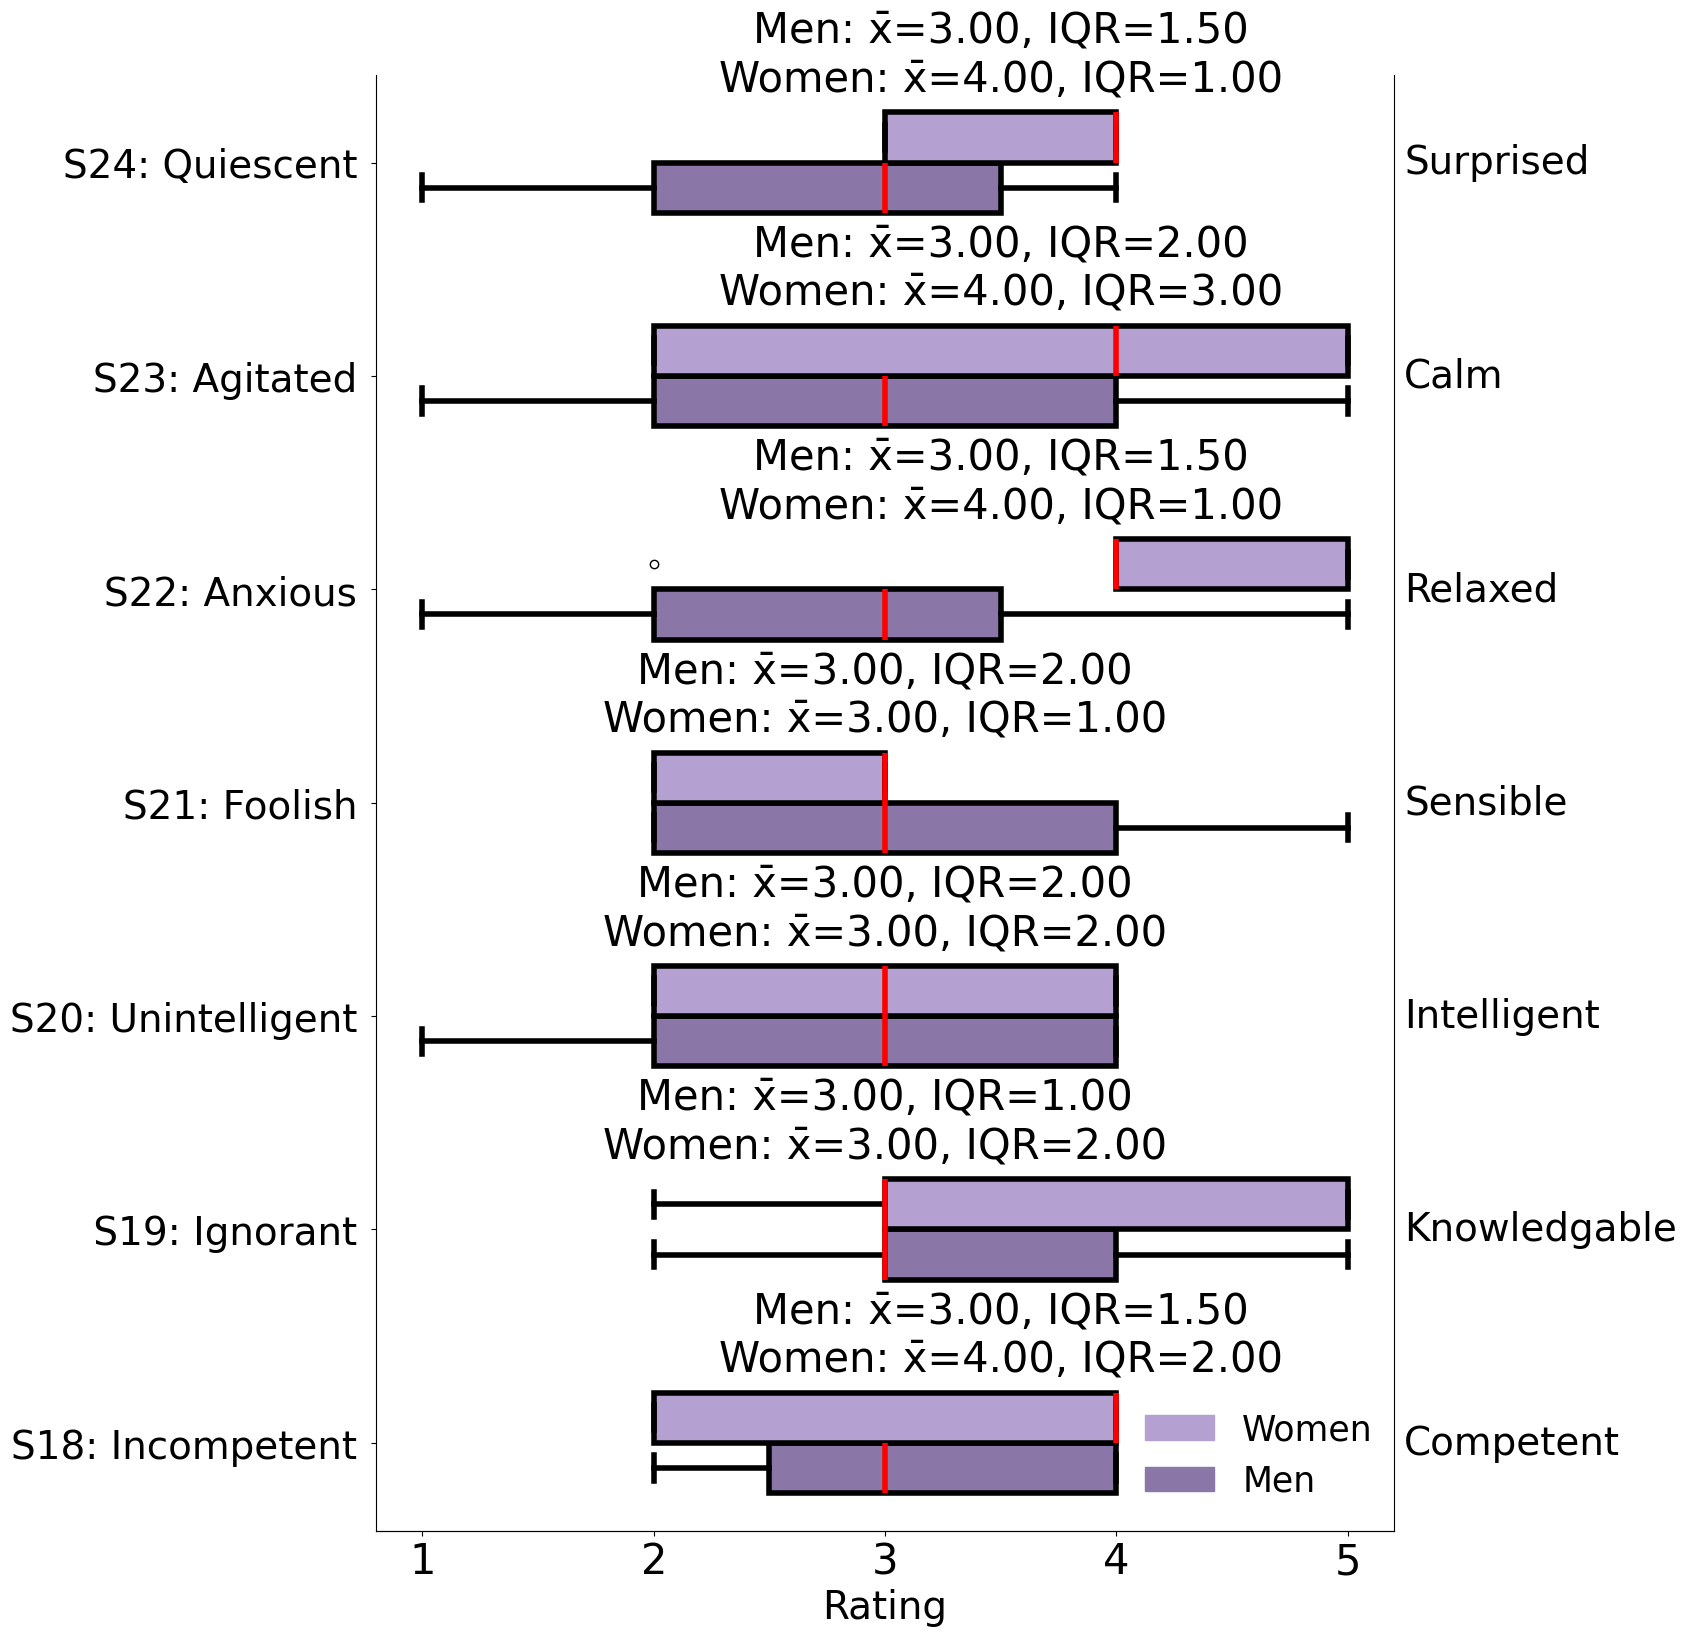

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === CONFIGURATION ===
excel_path_men   = "/content/plot_ready_data_men-finalfinal.xlsx"
excel_path_women = "/content/plot_ready_data_woman-finalfinal.xlsx"

rows_to_plot = [17, 18, 19, 20, 21, 22, 23]  # specify which rows (0 = first row after header)
SAVE_PATH_SVG = "fig16.svg"   # true vector

left_labels  = ["S18: Incompetent", " S19: Ignorant", "S20: Unintelligent", "S21: Foolish", "S22: Anxious", "S23: Agitated", "S24: Quiescent"]
right_labels = ["Competent", "Knowledgable", "Intelligent", "Sensible", "Relaxed", "Calm", "Surprised"]


group_labels = ["Men", "Women"]
group_colors = ["#8b76a8", "#b5a1d1"]

figsize = (17, 16.5)
annotation_fontsize = 30
label_fontsize = 28
tick_fontsize = 30
median_linewidth = 4
box_edge_linewidth = 4
box_width = 0.4
spacing = 1.7  # vertical spacing between question rows





# === Load Data ===
df_men = pd.read_excel(excel_path_men)
df_women = pd.read_excel(excel_path_women)

df_men_plot = df_men.iloc[rows_to_plot]
df_women_plot = df_women.iloc[rows_to_plot]

data_men = df_men_plot.drop(columns=["S Number"]).apply(pd.to_numeric, errors='coerce')
data_women = df_women_plot.drop(columns=["S Number","Question"]).apply(pd.to_numeric, errors='coerce')

# === Plot setup ===
positions = np.arange(len(rows_to_plot)) * spacing
fig, ax = plt.subplots(figsize=figsize)
all_vals = []

# === Plot each question with two boxplots side by side ===
for i, (pos, left, right) in enumerate(zip(positions, left_labels, right_labels)):
    vals_m = data_men.iloc[i].dropna().values
    vals_w = data_women.iloc[i].dropna().values
    all_vals.extend(vals_m)
    all_vals.extend(vals_w)

    median_m = np.median(vals_m)
    median_w = np.median(vals_w)
    iqr_m = np.percentile(vals_m, 75) - np.percentile(vals_m, 25)
    iqr_w = np.percentile(vals_w, 75) - np.percentile(vals_w, 25)

    offset = box_width / 2

    # Men boxplot (left)
    box_m = ax.boxplot(
        vals_m,
        positions=[pos - offset],
        vert=False,
        widths=box_width,
        patch_artist=True,
        medianprops=dict(color='red', linewidth=median_linewidth),
        boxprops=dict(linewidth=box_edge_linewidth),
        whiskerprops=dict(linewidth=box_edge_linewidth),
        capprops=dict(linewidth=box_edge_linewidth)
    )
    for patch in box_m['boxes']:
        patch.set_facecolor(group_colors[0])

    # Women boxplot (right)
    box_w = ax.boxplot(
        vals_w,
        positions=[pos + offset],
        vert=False,
        widths=box_width,
        patch_artist=True,
        medianprops=dict(color='red', linewidth=median_linewidth),
        boxprops=dict(linewidth=box_edge_linewidth),
        whiskerprops=dict(linewidth=box_edge_linewidth),
        capprops=dict(linewidth=box_edge_linewidth)
    )
    for patch in box_w['boxes']:
        patch.set_facecolor(group_colors[1])

    # Annotation above tallest cap
    # === Control vertical padding above boxplots
    annotation_padding = 0.5  # ← increase this to push annotations further away

    top_y = max(box_m['caps'][1].get_ydata()[0], box_w['caps'][1].get_ydata()[0])
    mid_x = (np.median(vals_m) + np.median(vals_w)) / 2

    annotation = (
        f"Men: x̄={median_m:.2f}, IQR={iqr_m:.2f}\n"
        f"Women: x̄={median_w:.2f}, IQR={iqr_w:.2f}"
    )
    ax.text(
        mid_x,
        pos + annotation_padding,
        annotation,
        ha='center',
        va='bottom',
        fontsize=annotation_fontsize
    )

# === Y-axis labels (construct semantics)
ax.set_yticks(positions)
ax.set_yticklabels(left_labels, fontsize=label_fontsize, ha='right')
ax.tick_params(axis='x', labelsize=tick_fontsize)

# === Right-side labels (opposite meanings)
# === Right-side labels (opposite meanings)
# === Right-side labels (opposite meanings)
# === Right-side labels (opposite meanings)
ax2 = ax.twinx()
ax2.set_yticks([])  # remove default right-side ticks

for pos, label in zip(positions, right_labels):
    ax2.text(
        1.01, pos,  # 1.01 = just to the right of the axis
        label,
        transform=ax.get_yaxis_transform(),  # align to same scale as ax
        fontsize=label_fontsize,
        ha='left',
        va='center'
    )
ax2.tick_params(axis='y', length=0, pad=10)
ax.tick_params(axis='y', pad=10)  # match left-side label padding
ax2.spines['top'].set_visible(False)

# === Final touches ===
ax.set_xlabel("Rating", fontsize=label_fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
print("\n📊 Raw participant data used for plotting:\n")
for i, (row_idx, left, right) in enumerate(zip(rows_to_plot, left_labels, right_labels)):
    vals_m = data_men.iloc[i].dropna().values
    vals_w = data_women.iloc[i].dropna().values

    print(f"--- Row {row_idx + 2} | {left} ↔ {right} ---")
    print(f"Men   ({len(vals_m)} responses): {vals_m}")
    print(f"Women ({len(vals_w)} responses): {vals_w}")
    print()
# === Legend
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color=group_colors[1], label=group_labels[1]),
    mpatches.Patch(color=group_colors[0], label=group_labels[0])

]
legend=ax.legend(handles=legend_handles, loc='lower right', fontsize=25, bbox_to_anchor=(1.01, 0.001))  # move right by increasing the x value)
legend.set_frame_on(False)

plt.tight_layout()
plt.rcParams["svg.fonttype"] = "path"  # <- force text to vector paths
plt.savefig(SAVE_PATH_SVG, format="svg", bbox_inches="tight")

plt.show()


#Binary

In [ ]:
import pandas as pd


df = pd.read_excel("/content/yes no response.xlsx", header=None)

cleaned = []
i = 0
while i < len(df):
    cell = str(df.iloc[i, 0]).strip().lower()


    if cell not in ['yes', 'no', 'nan', '']:
        question = df.iloc[i, 0].strip()
        yes_count = 0
        no_count = 0


        if i + 1 < len(df) and str(df.iloc[i+1, 0]).strip().lower() == 'yes':
            yes_count = df.iloc[i+1, 1]

        if i + 2 < len(df) and str(df.iloc[i+2, 0]).strip().lower() == 'no':
            no_count = df.iloc[i+2, 1]

        print(f"📌 Found question: {question} | Yes: {yes_count} | No: {no_count}")

        cleaned.append({
            "Question": question,
            "Yes": int(yes_count) if pd.notna(yes_count) else 0,
            "No": int(no_count) if pd.notna(no_count) else 0
        })

        i += 3
    else:
        i += 1


out = pd.DataFrame(cleaned)


out.to_excel("yes_no_cleaned.xlsx", index=False)
print("✅ Cleaned yes/no summary saved to 'yes_no_cleaned-men.xlsx'")

📌 Found question: Did the robot help enhance your understanding of the lecture material? | Yes: 4.0 | No: 17.0
📌 Found question: Did the robot's use of gestures complement the delivery of the material? | Yes: 18.0 | No: 3.0
📌 Found question: Do you agree with the following statement: “I think the robot can deliver informative lectures.” | Yes: 10.0 | No: 11.0
📌 Found question: Do you agree with the following statement: “I think the robot + LLM system is flexible enough to create a presentation which suits the entire class (e.g., suits different learning styles).” | Yes: 4.0 | No: 17.0
📌 Found question: Would you recommend robot-presented lectures to other students? | Yes: 9.0 | No: 12.0
📌 Found question: Did the robot's gestures and movements enhance your engagement? | Yes: 16.0 | No: 5.0
📌 Found question: Do you agree with the following statement: “I was so involved in the interaction that I lost track of time.” | Yes: 5.0 | No: 16.0
📌 Found question: Do you agree with the following s

In [ ]:
import pandas as pd
from openpyxl.utils import column_index_from_string

# === CONFIGURATION ===
INPUT_FILE = "/content/man_Responses_paper_complete.xlsx"
OUTPUT_FILE = "yes_no_tally-men.xlsx"
QUESTION_COLUMNS = ['H', 'I', 'M', 'N', 'Q', 'T', 'U', 'V', 'Y', 'Z', 'AA', 'AD', 'AF', 'AG', 'AH', 'AJ', 'AK']
N_RESPONSE_ROWS = 11  # Number of response rows (excluding question row)

# === Convert Excel letters to 0-based indices ===
column_indices = [column_index_from_string(col) - 1 for col in QUESTION_COLUMNS]

# === Load entire sheet as raw (no header inference) ===
df_raw = pd.read_excel(INPUT_FILE, header=None)

# === Extract question and responses ===
results = []
for col_idx in column_indices:
    question = df_raw.iloc[0, col_idx]  # row 0 = question
    responses = df_raw.iloc[1:N_RESPONSE_ROWS+1, col_idx]  # rows 1 to N = responses

    responses = responses.astype(str).str.strip().str.title()
    yes_count = (responses == 'Yes').sum()
    no_count  = (responses == 'No').sum()

    results.append({
        "Question": question,
        "Yes Count": yes_count,
        "No Count": no_count
    })

# === Save to Excel ===
output_df = pd.DataFrame(results)
output_df.to_excel(OUTPUT_FILE, index=False)

print(f"Tally saved to: {OUTPUT_FILE}")

Tally saved to: yes_no_tally-men.xlsx


/tmp/ipython-input-2171734656.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2)


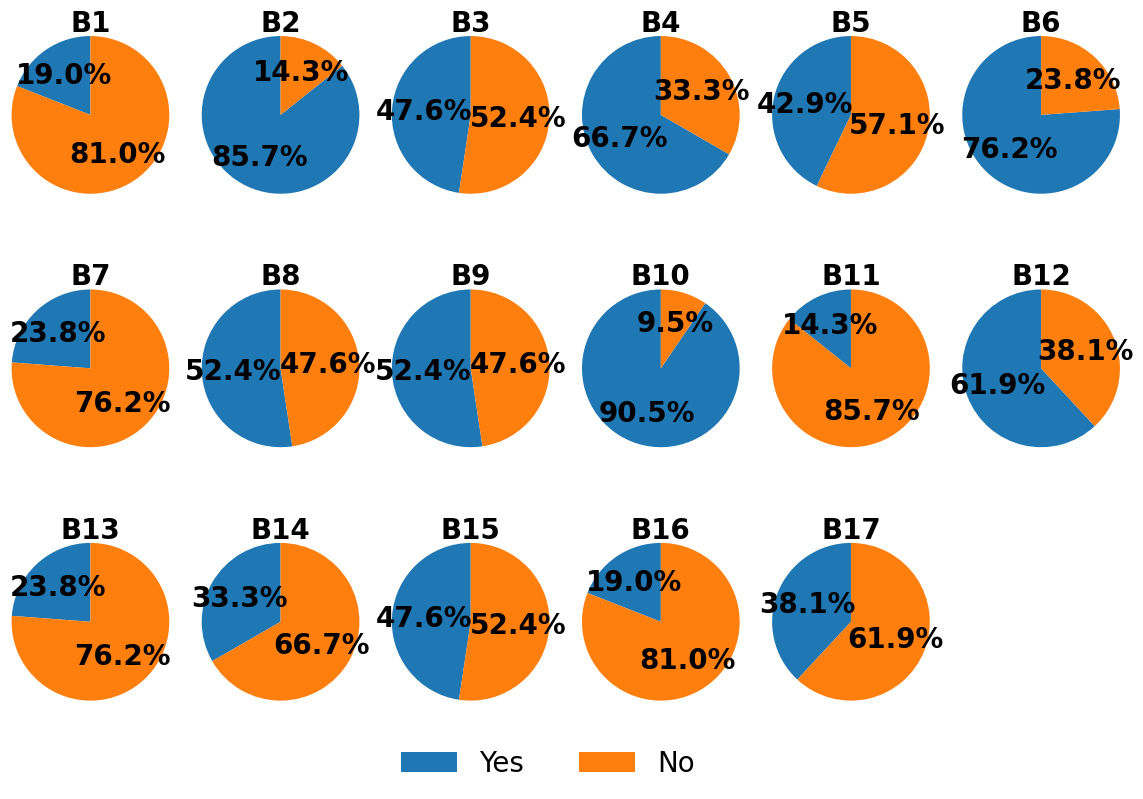

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

SAVE_PATH_SVG = "fig10.svg"   # true vector


# === CONFIG ===
EXCEL_PATH          = "/content/yes_no_cleaned-3-final.xlsx"
ROWS_TO_PLOT        = list(range(17))
N_COLS              = 6

# Font sizes
FONT_SIZE_AUTOPCT   = 20
FONT_SIZE_B_LABEL   = 20

# Spacing
VERTICAL_SPACE      = 0.2
HORIZONTAL_SPACE    = 0.15

# === Load + Process Data ===
df = pd.read_excel(EXCEL_PATH).iloc[ROWS_TO_PLOT].assign(
    Total   = lambda d: d.Yes + d.No,
    Yes_pct = lambda d: d.Yes / d.Total * 100,
    No_pct  = lambda d: d.No  / d.Total * 100
)

# layout
n      = len(df)
n_rows = int(np.ceil(n / N_COLS))
fig    = plt.figure(figsize=(N_COLS * 2.4, n_rows * 3.2), constrained_layout=False)

gs = GridSpec(
    n_rows * 2, N_COLS, figure=fig,
    height_ratios=[1, 0.5] * n_rows,
    hspace=VERTICAL_SPACE,
    wspace=HORIZONTAL_SPACE
)

colors = ["tab:blue", "tab:orange"]
for idx, row in enumerate(df.itertuples()):
    r, c = divmod(idx, N_COLS)
    ax = fig.add_subplot(gs[2*r, c])
    wedges, _, autotexts = ax.pie(
        [row.Yes_pct, row.No_pct],
        labels=None,                # remove slice labels
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        radius=1.4
    )
    for a in autotexts:
        a.set_fontsize(FONT_SIZE_AUTOPCT)
        a.set_fontweight("bold")
    ax.set(aspect="equal", xticks=[], yticks=[])
    ax.text(0.5, 1.05, f"B{idx+1}", transform=ax.transAxes,
            ha='center', va='bottom',
            fontsize=FONT_SIZE_B_LABEL, fontweight='bold')

# add legend at bottom center
legend_handles = [Patch(facecolor=colors[0], label="Yes"),
                  Patch(facecolor=colors[1], label="No")]
fig.legend(handles=legend_handles,
           loc='lower center',
           ncol=2,
           frameon=False,
           bbox_to_anchor=(0.5, 0.09),
           fontsize=FONT_SIZE_AUTOPCT)

plt.tight_layout(pad=2)
plt.rcParams["svg.fonttype"] = "path"  # <- force text to vector paths
plt.savefig(SAVE_PATH_SVG, format="svg", bbox_inches="tight")
plt.show()

In [ ]:
!jupyter nbconvert --to html /content/statsLLMLecgoodcopy.ipynb

[NbConvertApp] Converting notebook /content/statsLLMLecgoodcopy.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1877225 bytes to /content/statsLLMLecgoodcopy.html


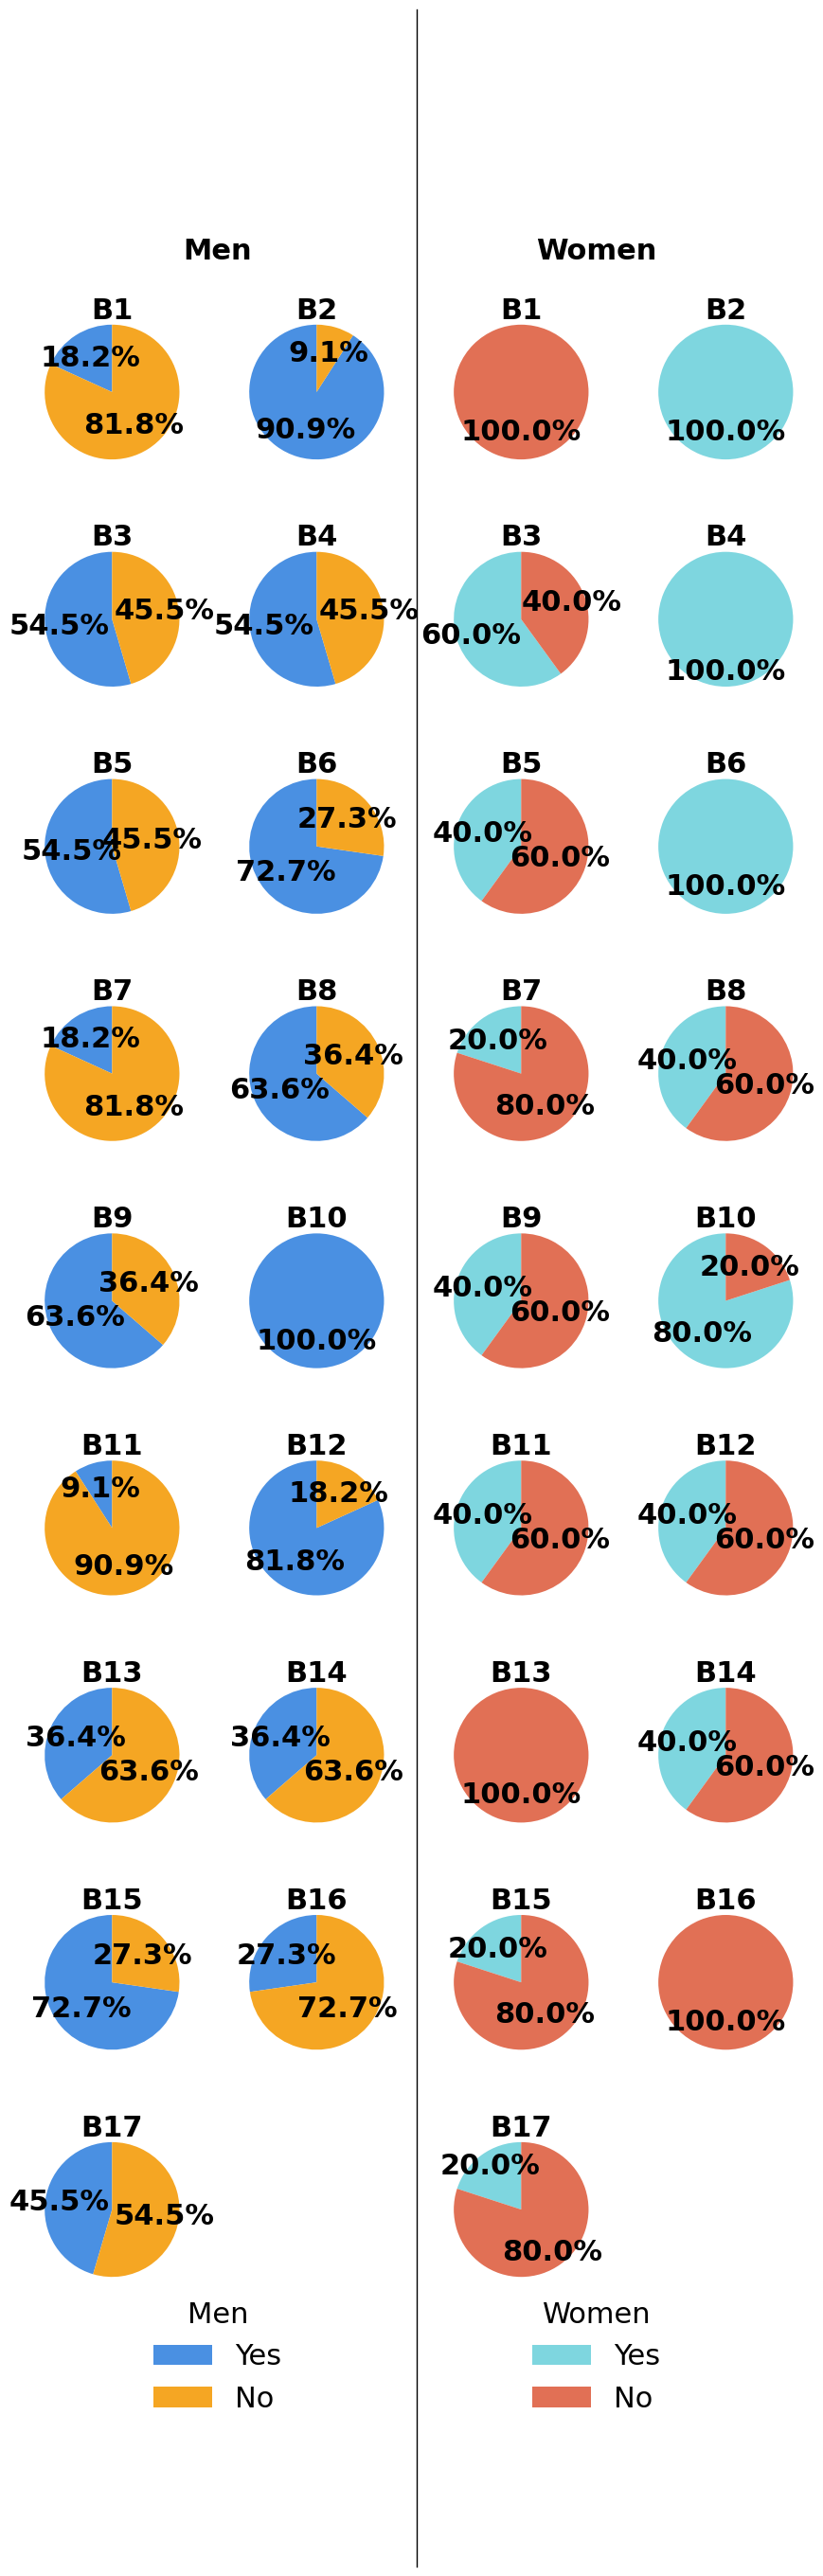

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.lines as mlines
from matplotlib.patches import Patch

def autopct_no_zeros(pct):
    return f"{pct:.1f}%" if pct >= 0.1 else ""

SAVE_PATH_SVG = "fig17.svg"   # true vector


# === CONFIG ===
EXCEL_PATH_W = "/content/yes_no_tally-woman-final.xlsx"
EXCEL_PATH_M = "/content/yes_no_tally-men-final.xlsx"
ROWS_TO_PLOT = list(range(17))
N_COLS = 2

# Font sizes
FONT_SIZE_AUTOPCT = 22
FONT_SIZE_HEADER = 22
FONT_SIZE_STAT = 22

# Spacing
VERTICAL_SPACE = 0.5
HORIZONTAL_SPACE = 0.7
LABEL_OFFSET = 1.1  # distance from center for percentage labels
SPACED_LABELS = {2,3,16}  # <- indices of plots where label offset is applied

# === Load data ===
df_m = pd.read_excel(EXCEL_PATH_M).iloc[ROWS_TO_PLOT]
df_w = pd.read_excel(EXCEL_PATH_W).iloc[ROWS_TO_PLOT]

# Compute percentages
for df in (df_m, df_w):
    df["Total"] = df["Yes"] + df["No"]
    df["Yes_pct"] = df["Yes"] / df["Total"] * 100
    df["No_pct"] = df["No"] / df["Total"] * 100

# Layout
n = len(df_m)
n_rows = int(np.ceil(n / N_COLS))

fig = plt.figure(
    figsize=(N_COLS * 2.5 * 2, n_rows * 3),
    constrained_layout=False
)

# Vertical divider
divider = mlines.Line2D([0.51, 0.51], [0, 1],
                        transform=fig.transFigure,
                        color='black', linewidth=1)
fig.add_artist(divider)

# Headers
fig.text(0.3, 0.9, "Men",
         ha='center', va='bottom',
         fontsize=FONT_SIZE_HEADER, fontweight='bold')
fig.text(0.7, 0.9, "Women",
         ha='center', va='bottom',
         fontsize=FONT_SIZE_HEADER, fontweight='bold')

gs = GridSpec(
    n_rows, N_COLS * 2, figure=fig,
    hspace=VERTICAL_SPACE,
    wspace=HORIZONTAL_SPACE
)

for idx in range(n):
    r = idx // N_COLS
    c = idx % N_COLS

    # --- Men plot ---
    ax_m = fig.add_subplot(gs[r, c])
    wedges_m, _, autotexts_m = ax_m.pie(
        [df_m.Yes_pct.iloc[idx], df_m.No_pct.iloc[idx]],
        labels=None,
        autopct=autopct_no_zeros,
        startangle=90,
        colors=["#4a90e2", "#f5a623"],
        radius=1.4
    )
    for i, a in enumerate(autotexts_m):
        a.set_fontsize(FONT_SIZE_AUTOPCT)
        a.set_fontweight("bold")
        if idx in SPACED_LABELS:
            angle = (wedges_m[i].theta2 + wedges_m[i].theta1) / 2
            x = LABEL_OFFSET * np.cos(np.deg2rad(angle))
            y = LABEL_OFFSET * np.sin(np.deg2rad(angle))
            a.set_position((x, y))
    ax_m.set(aspect="equal", xticks=[], yticks=[])
    ax_m.set_title(f"B{idx+1}", pad=10,
                   fontsize=FONT_SIZE_STAT, fontweight='bold')

    # --- Women plot ---
    ax_w = fig.add_subplot(gs[r, c + N_COLS])
    wedges_w, _, autotexts_w = ax_w.pie(
        [df_w.Yes_pct.iloc[idx], df_w.No_pct.iloc[idx]],
        labels=None,
        autopct=autopct_no_zeros,
        startangle=90,
        colors=["#7ed6df", "#e17055"],
        radius=1.4
    )
    for i, a in enumerate(autotexts_w):
        a.set_fontsize(FONT_SIZE_AUTOPCT)
        a.set_fontweight("bold")
        if idx in SPACED_LABELS:
            angle = (wedges_w[i].theta2 + wedges_w[i].theta1) / 2
            x = LABEL_OFFSET * np.cos(np.deg2rad(angle))
            y = LABEL_OFFSET * np.sin(np.deg2rad(angle))
            a.set_position((x, y))
    ax_w.set(aspect="equal", xticks=[], yticks=[])
    ax_w.set_title(f"B{idx+1}", pad=10,
                   fontsize=FONT_SIZE_STAT, fontweight='bold')

# Legends
legend_m = [
    Patch(facecolor="#4a90e2", label="Yes"),
    Patch(facecolor="#f5a623", label="No")
]
legend_w = [
    Patch(facecolor="#7ed6df", label="Yes"),
    Patch(facecolor="#e17055", label="No")
]

fig.legend(handles=legend_m,
           loc='lower center',
           bbox_to_anchor=(0.3, 0.05),
           frameon=False,
           title="Men",
           title_fontsize=FONT_SIZE_AUTOPCT,
           fontsize=FONT_SIZE_AUTOPCT)

fig.legend(handles=legend_w,
           loc='lower center',
           bbox_to_anchor=(0.7, 0.05),
           frameon=False,
           title="Women",
           title_fontsize=FONT_SIZE_AUTOPCT,
           fontsize=FONT_SIZE_AUTOPCT)

plt.subplots_adjust(wspace=1, hspace=VERTICAL_SPACE)
plt.rcParams["svg.fonttype"] = "path"  # <- force text to vector paths
plt.savefig(SAVE_PATH_SVG, format="svg", bbox_inches="tight")
plt.show()


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# Load Excel files
men_df = pd.read_excel('/content/yes_no_tally-men-final.xlsx')     # Replace with actual filename
women_df = pd.read_excel('/content/yes_no_tally-woman-final.xlsx') # Replace with actual filename



# Collect output for Excel
results = []

# Loop through each question (rows 2–17 = index 1–16)
for i in range(0, 17):
    question = men_df.iloc[i, 0]  # Column A
    men_yes = men_df.iloc[i, 2]   # Column C = index 2
    men_no  = men_df.iloc[i, 4]   # Column E = index 4
    women_yes = women_df.iloc[i, 2]
    women_no  = women_df.iloc[i, 4]

    # Create contingency table
    table = [[men_yes, men_no],
             [women_yes, women_no]]

    # Run Chi-square test
    chi2, p, dof, expected = chi2_contingency(table)

    # Append row to results
    results.append({
        "Question": question,
        "Men_Yes": men_yes,
        "Men_No": men_no,
        "Women_Yes": women_yes,
        "Women_No": women_no,
        "Chi2": round(chi2, 3),
        "p_value": round(p, 4),
        "Significant (p < 0.05)": "Yes" if p < 0.05 else "No"
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Save to Excel
results_df.to_excel("chi_square_results.xlsx", index=False)

# Display in notebook
print("✅ Results saved to chi_square_results.xlsx")
display(results_df)

✅ Results saved to chi_square_results.xlsx


,Question,Men_Yes,Men_No,Women_Yes,Women_No,Chi2,p_value,Significant (p < 0.05)
0,B1,2,9,0,5,0.042,0.8385,No
1,B2,10,1,5,0,0.000,1.0000,No
2,B3,6,5,3,2,0.000,1.0000,No
3,B4,6,5,5,0,1.529,0.2163,No
4,B5,6,5,2,3,0.000,1.0000,No
5,B6,8,3,5,0,0.366,0.5455,No
6,B7,2,9,1,4,0.000,1.0000,No
7,B8,7,4,2,3,0.115,0.7340,No
8,B9,7,4,2,3,0.115,0.7340,No
9,B10,11,0,4,1,0.175,0.6761,No


In [ ]:
import pandas as pd
from scipy.stats import fisher_exact

# === Load Files ===
men_df = pd.read_excel("yes_no_tally-men-final.xlsx")
women_df = pd.read_excel("yes_no_tally-woman-final.xlsx")

# === Store Results ===
results = []

# Loop through each question
for i in range(len(men_df)):
    question_men = men_df.iloc[i, 1]     # 'Question (MALE)'
    men_yes = men_df.iloc[i, 2]          # 'Yes'
    men_no  = men_df.iloc[i, 4]          # 'No'

    question_women = women_df.iloc[i, 1] # 'Question (FEMALE)'
    women_yes = women_df.iloc[i, 2]      # 'Yes'
    women_no  = women_df.iloc[i, 4]      # 'No'

    # Print verification
    print(f"\n--- Question {i + 1} ---")
    print(f"Men Q: {question_men}")
    print(f"→ Men Yes: {men_yes}, No: {men_no}")
    print(f"Women Q: {question_women}")
    print(f"→ Women Yes: {women_yes}, No: {women_no}")

    # 2x2 contingency table
    table = [[men_yes, men_no], [women_yes, women_no]]

    # Fisher's Exact Test
    try:
        oddsratio, p = fisher_exact(table)
    except ValueError as e:
        print(f"⚠️ Skipping due to error: {e}")
        continue

    results.append({
        "Question": question_men,
        "Men_Yes": men_yes,
        "Men_No": men_no,
        "Women_Yes": women_yes,
        "Women_No": women_no,
        "Fisher_p_value": round(p, 4),
        "Significant (p < 0.05)": "Yes" if p < 0.05 else "No"
    })
for idx, row in results_df.iterrows():
    print(f"{idx+1:02d}. p = {row['Fisher_p_value']} → Significant: {row['Significant (p < 0.05)']}")
# Convert to DataFrame and export
results_df = pd.DataFrame(results)
results_df.to_excel("fisher_exact_results.xlsx", index=False)

print("\n✅ Fisher's Exact Test complete. Results saved to 'fisher_exact_results.xlsx'")
results_df.head()


--- Question 1 ---
Men Q: Did the robot help enhance your understanding of the lecture material?
→ Men Yes: 2, No: 9
Women Q: Did the robot help enhance your understanding of the lecture material?
→ Women Yes: 0, No: 5

--- Question 2 ---
Men Q: Did the robot's use of gestures complement the delivery of the material?
→ Men Yes: 10, No: 1
Women Q: Did the robot's use of gestures complement the delivery of the material?
→ Women Yes: 5, No: 0

--- Question 3 ---
Men Q: Do you agree with the following statement: “I think the robot can deliver informative lectures.”
→ Men Yes: 6, No: 5
Women Q: Do you agree with the following statement: “I think the robot can deliver informative lectures.”
→ Women Yes: 3, No: 2

--- Question 4 ---
Men Q: Do you believe robots can effectively supplement human teaching?
→ Men Yes: 6, No: 5
Women Q: Do you believe robots can effectively supplement human teaching?
→ Women Yes: 5, No: 0

--- Question 5 ---
Men Q: Would you recommend robot-presented lectures to 

,Question,Men_Yes,Men_No,Women_Yes,Women_No,Fisher_p_value,Significant (p < 0.05)
0,Did the robot help enhance your understanding ...,2,9,0,5,1.0000,No
1,Did the robot's use of gestures complement the...,10,1,5,0,1.0000,No
2,Do you agree with the following statement: “I ...,6,5,3,2,1.0000,No
3,Do you believe robots can effectively suppleme...,6,5,5,0,0.1186,No
4,Would you recommend robot-presented lectures t...,6,5,2,3,1.0000,No
